# **Анализ отзывов ночных заведений в Москве**


##### **В этом анализе мы будем работать с данными, полученными через API из Google Maps. Для получения данных был использован сторонний SerpApi и из-за ограничения в запросах было принято решение взять по 4 страницы отзывов (примерно 65 отзывов) с выборки из 25 клубов.** #####

 Подробнее со списком ночных заведений можно ознаокмиться в файле *clubs.txt* . Получение данных реализованно в файле clubs_reviews_api.py, сами данные были записаны в файл *club_reviews.csv*, c которого мы и начнем работу.

**Логика проекта:** Оценка на картах — прокси удовлетворенности и главный публичный сигнал для новых посетителей. Ее влияние на бизнес измерено: Luca (2016) на данных Yelp и налоговой отчетности показал, что рост рейтинга на одну звезду повышает выручку независимого заведения на 5–9%. Удовлетворенность связана и с намерением вернуться, причем асимметрично: недостаток качества влияет сильнее, чем избыток (Anderson & Sullivan, 1993).

**Задача:** понять, какие проблемы сильнее тянут вниз публичную оценку, и куда направить ресурсы в первую очередь.

**Бизнес-цель:** повысить удовлетворенность посетителей ночных заведений в Москве и увеличить повторные посещения клуба.

**Гипотеза:** темы жалоб различаются по силе связи с рейтингом — часть упоминается часто, но на оценку почти не влияет, часть встречается реже, но сопровождается заметно более низкими оценками.

Предполагается, что частота темы и ее связь с рейтингом — разные вещи. Темы, связанные с отношением к гостю (вход, охрана, персонал), должны сопровождаться более низкой оценкой заведения, поскольку воспринимаются как несправедливость, а не как недостаток продукта. Темы, связанные с ожидаемыми свойствами формата (цены, очереди, громкость), могут упоминаться часто, но на итоговую оценку влиять слабо — гость знает, на что идет.

**Задача аналитика:** по реальным отзывам определить, чем недовольны посетители, какие проблемы чаще сопровождаются низкими оценками и что стоит исправить первым.

**Ограничение:** данные не позволяют наблюдать повторные визиты. Связь между удовлетворенностью и возвращаемостью берется на основе других исследований, а не проверяется в этой работе.

**Источники:**
- Luca, M. (2016). [DOI: 10.1287/mksc.12.2.125](https://pubsonline.informs.org/doi/abs/10.1287/mksc.12.2.125)
- Anderson, E. W., & Sullivan, M. W. (1993). [SSRN: 1928601](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=1928601)

## Оглавление

- Импорт библиотек
- 1. Загрузка и обзор данных
- 2. Очистка данных
- 3. EDA
  - 3.1 Покрытие выборки
  - 3.2 Распределение отзывов по годам
  - 3.3 Проверка статуса заведений
  - 3.4 Обработка закрытых заведений
  - 3.5 Распределение оценок по всей выборке
  - 3.6 Доля негатива по клубам
  - 3.7 Кто оставляет текст
  - 3.8 `club_rating` против средней по выборке
  - 3.9 Распределение `club_rating`
- 4. NLP с подключением LLM
  - 4.1 Подключение GENAI
  - 4.2 Тест классификатора на одном отзыве c GEMINI 2.5
  - 4.3 Валидация LLM-классификатора
  - 4.4 Оценка качества классификации
  - 4.5 Разметка полного корпуса отзывов
- 5. Анализ результатов
  - 5.1 Формирование итогового размеченного датасета
  - 5.2 Описательный анализ жалоб
  - 5.3 Приоритизация жалоб по частоте и индексу тяжести
  - 5.4 Сравнение профиля жалоб между клубами
  - 5.5 Итоговые выводы

# Импорт библиотек

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
from dotenv import load_dotenv

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [2]:
%matplotlib inline
from statsmodels.stats.proportion import proportion_confint

## 1. Загрузка и обзор данных

In [3]:
df = pd.read_csv('data/club_reviews.csv') 
df.head(10)

,club,address,data_id,review_id,rating,date_iso,edited_at,date_label,text,original_text_available,source,review_url,collected_at,club_rating,club_reviews_total
0,Izi Moscow,"Басманный пер., 8 с1, Москва, Россия, 109028",0x46b54af49b7f665b:0xebbe3cfded529447,Ci9DQUlRQUNvZENodHljRjlvT2xaMGFGUlNibFp1Tm5sRm...,5.0,2026-08-05T08:53:05Z,2026-08-05T08:53:05Z,месяц назад,NaN,False,Google,https://www.google.com/maps/reviews/data=!4m8!...,2026-09-07T23:53:39.773458+00:00,3.4,84
1,Izi Moscow,"Басманный пер., 8 с1, Москва, Россия, 109028",0x46b54af49b7f665b:0xebbe3cfded529447,Ci9DQUlRQUNvZENodHljRjlvT2xwWlJWcEJlSEZuU1c5bl...,5.0,2026-07-25T21:02:18Z,2026-07-25T21:02:18Z,месяц назад,"ништяк место, можно потусить",True,Google,https://www.google.com/maps/reviews/data=!4m8!...,2026-09-07T23:53:39.773816+00:00,3.4,84
2,Izi Moscow,"Басманный пер., 8 с1, Москва, Россия, 109028",0x46b54af49b7f665b:0xebbe3cfded529447,Ci9DQUlRQUNvZENodHljRjlvT2pCUWRUaGpkbVIyU0ZOMF...,5.0,2026-07-17T22:24:34Z,2026-07-17T22:24:34Z,месяц назад,Крутой движ,True,Google,https://www.google.com/maps/reviews/data=!4m8!...,2026-09-07T23:53:39.773864+00:00,3.4,84
3,Izi Moscow,"Басманный пер., 8 с1, Москва, Россия, 109028",0x46b54af49b7f665b:0xebbe3cfded529447,Ci9DQUlRQUNvZENodHljRjlvT2toYVRYQk1jalJsYVhaQl...,5.0,2026-07-17T22:24:03Z,2026-07-17T22:24:03Z,месяц назад,NaN,False,Google,https://www.google.com/maps/reviews/data=!4m8!...,2026-09-07T23:53:39.773900+00:00,3.4,84
4,Izi Moscow,"Басманный пер., 8 с1, Москва, Россия, 109028",0x46b54af49b7f665b:0xebbe3cfded529447,Ci9DQUlRQUNvZENodHljRjlvT25sSGFIVktRa1EzVWs1YW...,5.0,2026-07-17T22:23:24Z,2026-07-17T22:23:24Z,месяц назад,Изи кайф!!!,True,Google,https://www.google.com/maps/reviews/data=!4m8!...,2026-09-07T23:53:39.773932+00:00,3.4,84
5,Izi Moscow,"Басманный пер., 8 с1, Москва, Россия, 109028",0x46b54af49b7f665b:0xebbe3cfded529447,Ci9DQUlRQUNvZENodHljRjlvT2kxbFR6aGxXRTlSYURCd1...,5.0,2026-05-02T21:15:14Z,2026-05-02T21:15:14Z,4 месяца назад,NaN,False,Google,https://www.google.com/maps/reviews/data=!4m8!...,2026-09-07T23:53:39.934745+00:00,3.4,84
6,Izi Moscow,"Басманный пер., 8 с1, Москва, Россия, 109028",0x46b54af49b7f665b:0xebbe3cfded529447,Ci9DQUlRQUNvZENodHljRjlvT25WZmMwOXBiMHhOU0VnM1...,5.0,2026-04-25T20:48:46Z,2026-04-25T20:48:46Z,4 месяца назад,"Одним словом, Клуб огонь",True,Google,https://www.google.com/maps/reviews/data=!4m8!...,2026-09-07T23:53:39.934885+00:00,3.4,84
7,Izi Moscow,"Басманный пер., 8 с1, Москва, Россия, 109028",0x46b54af49b7f665b:0xebbe3cfded529447,Ci9DQUlRQUNvZENodHljRjlvT2xaTGFqQmtiV2wwUzFoTV...,5.0,2026-04-17T16:52:33Z,2026-04-17T16:52:33Z,4 месяца назад,"все очень круто, одно из немногих мест в Мск, ...",True,Google,https://www.google.com/maps/reviews/data=!4m8!...,2026-09-07T23:53:39.934986+00:00,3.4,84
8,Izi Moscow,"Басманный пер., 8 с1, Москва, Россия, 109028",0x46b54af49b7f665b:0xebbe3cfded529447,Ci9DQUlRQUNvZENodHljRjlvT2pSWVdYSlBUSGhUYlVGa1...,5.0,2026-04-17T11:17:52Z,2026-04-17T11:17:52Z,4 месяца назад,хороший клуб для посещений отдохнуть,True,Google,https://www.google.com/maps/reviews/data=!4m8!...,2026-09-07T23:53:39.935030+00:00,3.4,84
9,Izi Moscow,"Басманный пер., 8 с1, Москва, Россия, 109028",0x46b54af49b7f665b:0xebbe3cfded529447,Ci9DQUlRQUNvZENodHljRjlvT2sxVlYyRXRWalYwWlhkbm...,5.0,2026-03-07T21:07:04Z,2026-03-07T21:07:04Z,6 месяцев назад,Все круто,True,Google,https://www.google.com/maps/reviews/data=!4m8!...,2026-09-07T23:53:39.935066+00:00,3.4,84


In [4]:
df.describe()

,rating,club_rating,club_reviews_total
count,1600.000000,1600.000000,1600.000000
mean,3.746875,4.201125,1317.744375
std,1.723270,0.383671,1909.054954
min,1.000000,3.400000,37.000000
25%,1.000000,4.000000,93.000000
50%,5.000000,4.300000,548.000000
75%,5.000000,4.500000,1540.000000
max,5.000000,4.700000,7511.000000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1600 entries, 0 to 1599
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   club                     1600 non-null   str    
 1   address                  1600 non-null   str    
 2   data_id                  1600 non-null   str    
 3   review_id                1600 non-null   str    
 4   rating                   1600 non-null   float64
 5   date_iso                 1600 non-null   str    
 6   edited_at                1600 non-null   str    
 7   date_label               1600 non-null   str    
 8   text                     1044 non-null   str    
 9   original_text_available  1600 non-null   bool   
 10  source                   1600 non-null   str    
 11  review_url               1600 non-null   str    
 12  collected_at             1600 non-null   str    
 13  club_rating              1600 non-null   float64
 14  club_reviews_total       1600 non-n

In [6]:
df.isnull().sum()

club                         0
address                      0
data_id                      0
review_id                    0
rating                       0
date_iso                     0
edited_at                    0
date_label                   0
text                       556
original_text_available      0
source                       0
review_url                   0
collected_at                 0
club_rating                  0
club_reviews_total           0
dtype: int64

Видим, что в столбце text 556 нулевых значений - отзывов, где посетитель оставил оценку, но воздержался от комментария. Они исключаются только из NLP-анализа, но сохраняются при анализе рейтингов, поскольку содержат оценку пользователя. Поэтому правильным шагом будет позднее(после очистки датасэта) разделить данные на 2 датафрейма:
1) Со всеми отзывами(для анализа оценок и подсчета долей

2) Только с текстовыми отзывами(для NLP)

In [7]:
# Сохраняем изначальный датасет
df_raw = df.copy()

print(f'Количество строк: {df_raw.shape[0]}')
print(f'Количество столбцов: {df_raw.shape[1]}')

Количество строк: 1600
Количество столбцов: 15


In [8]:
# Считаем количество собранных отзывов по каждому клубу
club_counts = (
    df_raw['club']
    .value_counts(dropna=False)
    .rename_axis('club')
    .reset_index(name='counts')
)
club_counts

,club,counts
0,Happy End Bar&Kitchen,68
1,GIPSY,68
2,"Клуб ""Клуб""",68
3,16 Тонн,68
4,Мутабор,68
5,Gazgolder Club & Tea Room,68
6,Dissident,68
7,СМЕНА,68
8,RNDM,68
9,Микс Afterparty,68


In [9]:
df_raw['rating'].value_counts(dropna=False).sort_index()


rating
1.0    404
2.0     46
3.0     66
4.0    119
5.0    965
Name: count, dtype: int64

In [10]:
print('Минимальный рейтинг:', df_raw['rating'].min())
print('Максимальный рейтинг:', df_raw['rating'].max())
print('Уникальные значения:', sorted(df_raw['rating'].dropna().unique()))

date_check = pd.to_datetime(df_raw['date_iso'], errors='coerce', utc=True)
print('Самый ранний отзыв:', date_check.min())
print('Самый поздний отзыв:', date_check.max())
print('Дат, которые не удалось распознать:', date_check.isna().sum())

Минимальный рейтинг: 1.0
Максимальный рейтинг: 5.0
Уникальные значения: [1.0, 2.0, 3.0, 4.0, 5.0]
Самый ранний отзыв: 2017-04-02 22:33:05+00:00
Самый поздний отзыв: 2026-09-07 19:17:14+00:00
Дат, которые не удалось распознать: 0


In [11]:
df_raw['review_id'].duplicated().sum()

0

# 2. Очистка данных

In [12]:
df_clean = df_raw.copy()

In [13]:
#преобразуем столбец 'date_iso' в формат datetime
df_clean['date'] = pd.to_datetime(
    df_clean['date_iso'],
    errors='coerce',
    utc=True
)
print('Начало периода:', df_clean['date'].min())
print('Конец периода:', df_clean['date'].max())


Начало периода: 2017-04-02 22:33:05+00:00
Конец периода: 2026-09-07 19:17:14+00:00


In [14]:
df_clean['date'].dt.year.value_counts().sort_index()

date
2017      6
2018     16
2019     82
2020     51
2021    271
2022    259
2023    215
2024    218
2025    294
2026    188
Name: count, dtype: int64

In [15]:
#оставим только отзывы, оставленные после 1 января 2022 года
cutoff_date = pd.Timestamp('2022-01-01', tz='UTC')
rows_before= df_clean.shape[0]
df_clean = df_clean.loc[df_clean['date'] >= cutoff_date].copy()
rows_after = df_clean.shape[0]

print('Строк после фильтрации:', rows_after)
print('Удалено старых отзывов:', rows_before - rows_after)

Строк после фильтрации: 1174
Удалено старых отзывов: 426


In [16]:
df_clean['rating'] = df_clean['rating'].astype(int)

In [17]:
#обновляем индекс, чтобы он был последовательным
df_clean.reset_index(drop=True, inplace=True)

In [18]:
df_clean = df_clean.drop(columns=['date_iso',
                                    'address', 
                                    'data_id',  
                                    'edited_at',
                                    'date_label',  # неточная подпись «месяц назад»
                                    'original_text_available', # повторяет наличие текста
                                    'source',
                                    'collected_at'  # время выгрузки
                                    ])      
df_clean.head(10)

,club,review_id,rating,text,review_url,club_rating,club_reviews_total,date
0,Izi Moscow,Ci9DQUlRQUNvZENodHljRjlvT2xaMGFGUlNibFp1Tm5sRm...,5,NaN,https://www.google.com/maps/reviews/data=!4m8!...,3.4,84,2026-08-05 08:53:05+00:00
1,Izi Moscow,Ci9DQUlRQUNvZENodHljRjlvT2xwWlJWcEJlSEZuU1c5bl...,5,"ништяк место, можно потусить",https://www.google.com/maps/reviews/data=!4m8!...,3.4,84,2026-07-25 21:02:18+00:00
2,Izi Moscow,Ci9DQUlRQUNvZENodHljRjlvT2pCUWRUaGpkbVIyU0ZOMF...,5,Крутой движ,https://www.google.com/maps/reviews/data=!4m8!...,3.4,84,2026-07-17 22:24:34+00:00
3,Izi Moscow,Ci9DQUlRQUNvZENodHljRjlvT2toYVRYQk1jalJsYVhaQl...,5,NaN,https://www.google.com/maps/reviews/data=!4m8!...,3.4,84,2026-07-17 22:24:03+00:00
4,Izi Moscow,Ci9DQUlRQUNvZENodHljRjlvT25sSGFIVktRa1EzVWs1YW...,5,Изи кайф!!!,https://www.google.com/maps/reviews/data=!4m8!...,3.4,84,2026-07-17 22:23:24+00:00
5,Izi Moscow,Ci9DQUlRQUNvZENodHljRjlvT2kxbFR6aGxXRTlSYURCd1...,5,NaN,https://www.google.com/maps/reviews/data=!4m8!...,3.4,84,2026-05-02 21:15:14+00:00
6,Izi Moscow,Ci9DQUlRQUNvZENodHljRjlvT25WZmMwOXBiMHhOU0VnM1...,5,"Одним словом, Клуб огонь",https://www.google.com/maps/reviews/data=!4m8!...,3.4,84,2026-04-25 20:48:46+00:00
7,Izi Moscow,Ci9DQUlRQUNvZENodHljRjlvT2xaTGFqQmtiV2wwUzFoTV...,5,"все очень круто, одно из немногих мест в Мск, ...",https://www.google.com/maps/reviews/data=!4m8!...,3.4,84,2026-04-17 16:52:33+00:00
8,Izi Moscow,Ci9DQUlRQUNvZENodHljRjlvT2pSWVdYSlBUSGhUYlVGa1...,5,хороший клуб для посещений отдохнуть,https://www.google.com/maps/reviews/data=!4m8!...,3.4,84,2026-04-17 11:17:52+00:00
9,Izi Moscow,Ci9DQUlRQUNvZENodHljRjlvT2sxVlYyRXRWalYwWlhkbm...,5,Все круто,https://www.google.com/maps/reviews/data=!4m8!...,3.4,84,2026-03-07 21:07:04+00:00


Из датасета удалены технические и дублирующие столбцы: `data_id`, `date_iso`, `edited_at`, `date_label`, `source`, `collected_at`, `original_text_available` и `address`. Для анализа сохранены название клуба, уникальный ID, оценка, текст, дата и ссылка на отзыв. Общий рейтинг и количество отзывов клуба оставлены как дополнительные характеристики заведения.

In [19]:
df_nlp = df_clean.dropna(subset=['text']).copy()

print('Все отзывы:', len(df_clean))
print('Отзывы для NLP:', len(df_nlp))

Все отзывы: 1174
Отзывы для NLP: 853


# 3. EDA

### 3.1 Покрытие выборки

SerpApi отдаёт отзывы постранично и начиная с самых свежих, поэтому по каждому
клубу собрано ограниченное число последних отзывов, а не вся история. При этом
общее количество отзывов у заведений различается на два порядка: от 37 у LASKI
до 7511 у Молодёжи.

Это значит, что одна и та же метрика описывает для разных клубов разный объект:
для одних — все, что о заведении написано, для других — только последние месяцы.
Прежде чем сравнивать клубы между собой, оценим, какую долю отзывов заведения
мы фактически прочитали.

Колонка `downloaded` — сколько отзывов выгружено из API, `collected` — сколько
осталось после отсечки 2022 года, `total` — общее число отзывов у клуба по данным
Google на момент сбора.

In [20]:
coverage = (
    df_clean.groupby('club')
    .agg(collected=('review_id', 'size'),
         with_text=('text', 'count'),
         total=('club_reviews_total', 'first'),
         first_review=('date', 'min'),
         last_review=('date', 'max'))
    .join(df_raw.groupby('club').size().rename('downloaded'))
)

coverage['coverage_pct'] = (coverage['collected'] / coverage['total'] * 100).round(1)
coverage['text_share_pct'] = (coverage['with_text'] / coverage['collected'] * 100).round(1)

coverage = coverage[['downloaded', 'collected', 'with_text', 'text_share_pct',
                     'total', 'coverage_pct', 'first_review', 'last_review']] \
           .sort_values('coverage_pct')
coverage

,downloaded,collected,with_text,text_share_pct,total,coverage_pct,first_review,last_review
club,,,,,,,,
Dissident,68,1,1,100.0,276,0.4,2022-01-23 11:14:25+00:00,2022-01-23 11:14:25+00:00
Молодёжь,68,68,50,73.5,7511,0.9,2024-06-23 02:50:16+00:00,2026-09-07 19:17:14+00:00
16 Тонн,68,66,43,65.2,5904,1.1,2022-02-10 16:23:53+00:00,2026-06-26 19:31:13+00:00
МТ music bar,68,68,55,80.9,3754,1.8,2022-02-18 17:41:27+00:00,2026-08-01 21:55:31+00:00
Пропаганда,68,62,41,66.1,3226,1.9,2022-01-03 13:00:09+00:00,2026-08-14 10:01:10+00:00
Live Stars,68,29,12,41.4,1283,2.3,2022-01-02 21:35:43+00:00,2026-05-25 13:01:21+00:00
Бар 1929,68,51,36,70.6,1540,3.3,2022-01-01 03:33:06+00:00,2026-07-05 00:44:02+00:00
RNDM,68,15,10,66.7,389,3.9,2022-01-04 05:51:42+00:00,2026-06-12 16:41:38+00:00
"Бар ""Club Liberty""",68,63,44,69.8,1544,4.1,2022-01-02 17:24:47+00:00,2026-07-31 22:02:00+00:00


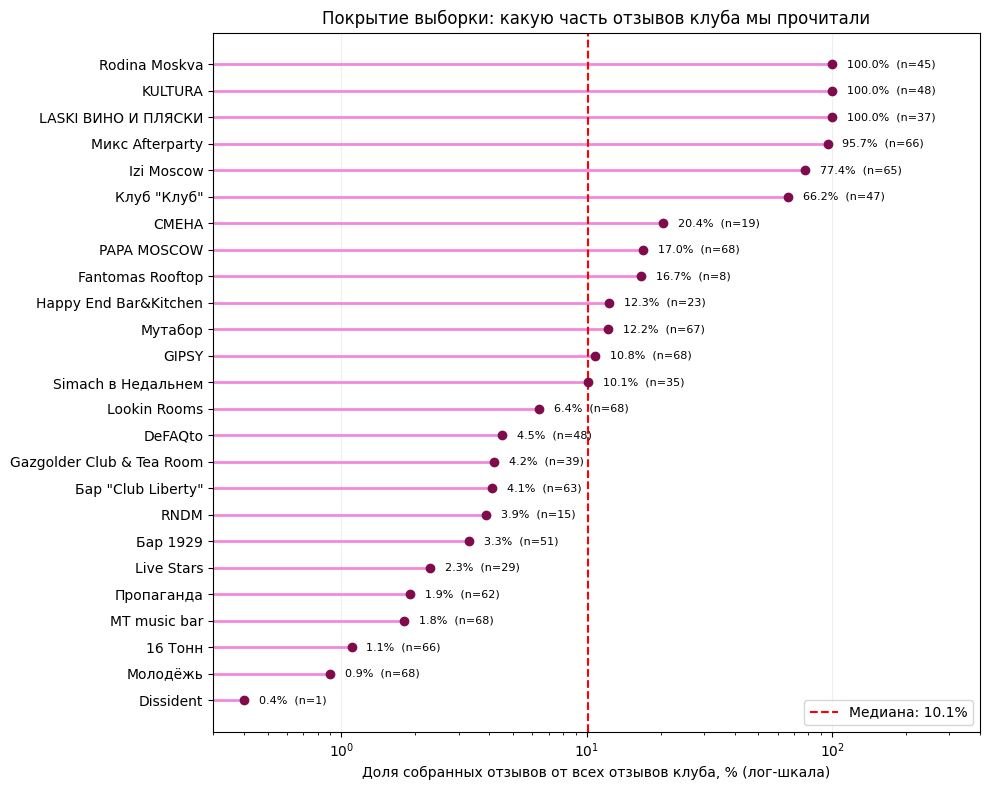

In [21]:
plot_df = coverage.sort_values('coverage_pct')

fig, ax = plt.subplots(figsize=(10, 8))
ax.hlines(plot_df.index, 0.3, plot_df['coverage_pct'], color="#F487DE", lw=2)
ax.scatter(plot_df['coverage_pct'], plot_df.index, color="#7F0B4D", zorder=3)

for club, row in plot_df.iterrows():
    ax.text(row['coverage_pct'] * 1.15, club,
            f"{row['coverage_pct']}%  (n={row['collected']})", va='center', fontsize=8)

median_coverage = plot_df['coverage_pct'].median()
ax.axvline(median_coverage, color='red', linestyle='--',
           label=f'Медиана: {median_coverage:.1f}%')

ax.set_xscale('log')
ax.set_xlim(0.3, 400)
ax.set_xlabel('Доля собранных отзывов от всех отзывов клуба, % (лог-шкала)')
ax.set_title('Покрытие выборки: какую часть отзывов клуба мы прочитали')
ax.grid(axis='x', alpha=0.2)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

Медианное покрытие составляет 10%: по половине клубов проанализирована десятая
часть отзывов или меньше. Полностью покрыты только Rodina Moskva, KULTURA и LASKI —
у этих заведений отзывов меньше, чем глубина выгрузки. На другом краю Молодёжь
и 16 Тонн с покрытием около 1%: их результаты описывают последние месяцы работы
заведения, а не весь накопленный опыт гостей.

Даты первого и последнего отзыва отражают ту же неоднородность. У Молодёжи и GIPSY
68 отзывов укладываются в два года, то есть заведения получают отзывы часто.
У Lookin Rooms последний отзыв датирован октябрём 2025 года, что требует проверки
текущего статуса заведения.

Доля отзывов с текстом также различается — от 41% у Live Stars до 96% у PAPA MOSCOW.
Поскольку темы жалоб извлекаются только из текста, доли тем далее рассчитываются
от числа текстовых отзывов, а не от всех собранных: иначе клубы, где гости реже
пишут комментарии, механически получили бы заниженные доли по всем темам.

### 3.2 Распределение отзывов по годам.

Оставим отзывы, опубликованные с 2022 года, чтобы ограничить давность данных и исключить 2020–2021 годы с ограничениями работы ночных заведений.

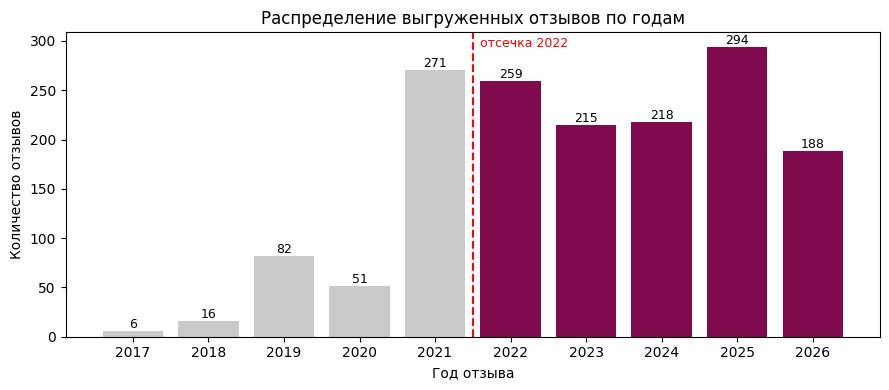

In [22]:
df_raw_new = df_raw.copy()
df_raw_new['date_iso'] = pd.to_datetime(df_raw_new['date_iso'])
by_year = df_raw_new['date_iso'].dt.year.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#C9C9C9' if y < 2022 else '#7F0B4D' for y in by_year.index]
bars = ax.bar(by_year.index.astype(str), by_year.values, color=colors)
ax.bar_label(bars, fontsize=9)

ax.axvline(4.5, color='red', linestyle='--', lw=1.5)
ax.text(4.6, by_year.max(), 'отсечка 2022', color='red', fontsize=9)

ax.set_ylabel('Количество отзывов')
ax.set_xlabel('Год отзыва')
ax.set_title('Распределение выгруженных отзывов по годам')
plt.tight_layout()
plt.show()

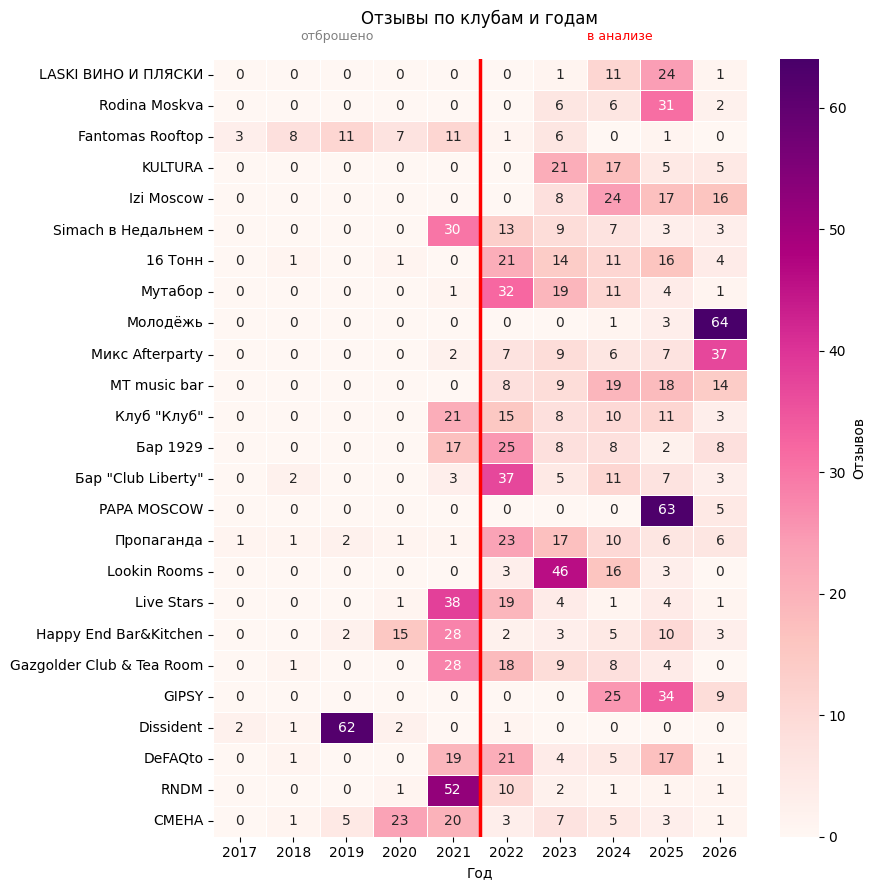

In [23]:
pivot_full = df_raw_new.pivot_table(index='club', columns=df_raw_new['date_iso'].dt.year,
                                values='review_id', aggfunc='size', fill_value=0)
pivot_full = pivot_full.loc[pivot_full.sum(axis=1).sort_values().index]

fig, ax = plt.subplots(figsize=(9, 9))
sns.heatmap(pivot_full, annot=True, fmt='d', cmap='RdPu',
            cbar_kws={'label': 'Отзывов'}, linewidths=.5, ax=ax)

cut = list(pivot_full.columns).index(2022)
ax.axvline(cut, color='red', lw=2.5)
ax.text(cut - 2, -0.6, 'отброшено', color='grey', ha='right', fontsize=9)
ax.text(cut + 2, -0.6, 'в анализе', color='red', ha='left', fontsize=9)

ax.set_xlabel('Год')
ax.set_ylabel('')
ax.set_title('Отзывы по клубам и годам', pad=25)
plt.tight_layout()
plt.show()

Даже после отсечки распределение отзывов по годам различается: одни клубы представлены преимущественно недавними отзывами, другие — отзывами за несколько лет. Это ограничивает сопоставимость клубов.

После отсечки в анализе осталось 1174 отзыва из 1600 выгруженных (73%).
Отброшено 426, из них 271 приходится на 2021 год, остальные распределены
по 2017–2020 годам тонким хвостом.

Отбрасывается не «старый шум»: причина в том, как устроена выгрузка.
Отзывы приходят от самых свежих к старым, поэтому одинаковые 68 отзывов
покрывают у разных клубов разные периоды. У Молодёжи, PAPA MOSCOW и GIPSY
до 2022 года нет ни одного отзыва — их поток настолько плотный, что выгрузка
не успевает уйти глубже. У Dissident 62 из 68 отзывов относятся к 2019 году,
у RNDM 52 — к 2021: эти заведения почти перестали получать отзывы.

Если оставить весь период, старые отзывы попадут в анализ практически только
от заглохших заведений, а активные клубы будут представлены исключительно
последними месяцами. Отсечка 2022 года выравнивает временное окно и делает
клубы сопоставимыми. Дополнительный аргумент — 2020–2021 годы приходятся
на ограничения работы ночных заведений, режим их работы отличался от текущего.

Тепловая карта показывает, что и после отсечки покрытие остается неравномерным:
у Молодёжи 64 из 68 отзывов относятся к 2026 году, у PAPA MOSCOW 63 из 68 —
к 2025, тогда как у Бара 1929 и Клуба «Клуб» отзывы распределены по всем пяти
годам. Это ограничение сохраняется и учитывается при интерпретации результатов.

Данные за 2026 год неполные: выгрузка сделана в сентябре 2026 года.

### 3.3 Проверка статуса заведений

Тепловая карта показала аномалию: у части клубов отзывы обрываются задолго
до момента выгрузки. Отзывы тянулись от новых к старым (`sort_by=newestFirst`),
поэтому пустые последние годы означают не пропуск в данных, а отсутствие
отзывов, то есть заведение перестало их получать.

Возможных причин две: клуб потерял популярность либо закрылся. Различить их
можно по тексту: гости, пришедшие к закрытой двери, обычно об этом пишут.
Поэтому стоит определить причину такой аномалии, для этого сделаем поиск упоминаний закрытия по ключевым словам.

In [24]:
closed_pattern = r'закрыт|не работает|закрылся|closed|shut down'
closed_mentions = df_clean[df_clean['text'].fillna('').str.contains(closed_pattern, case=False)]
closed_mentions.groupby('club').size().sort_values(ascending=False)

club
GIPSY                    3
Пропаганда               3
LASKI ВИНО И ПЛЯСКИ      2
Lookin Rooms             2
16 Тонн                  1
Happy End Bar&Kitchen    1
dtype: int64

Прочитаем каждый отзыв отдельно

In [25]:
pd.set_option('display.max_colwidth', None)

closed_pattern = r'закрыт|не работает|закрылся|closed|shut down'
closed_mentions = df_clean[df_clean['text'].fillna('').str.contains(closed_pattern, case=False)]

closed_mentions[['club', 'date', 'rating', 'text']].sort_values('date', ascending=False)

,club,date,rating,text
168,GIPSY,2026-07-06 07:22:59+00:00,5,"Был здесь на выпускном и завидовал выпускникам - в моё время о таком я даже не мог и мечтать -))\n\nКлуб давний, с историей; как оказалось, я тут был, но... лет 15 назад. А постепенно что-то начало вспоминаться -))\n\nGypsy - многоуровневый, что в нашем случае дало возможность разделить зону родителей и зону детей (у детей к родителям доступа не было, а родителей к детям - был).\nСцена и танцпол, вроде бы, небольшие, но места хватило всем.\n\nПрочитал в одном из отзывов (с другого выпускного), что организация была плохой.\nВ нашем случае организация была очень крутой.\nТо, что всех обыскивали - так клуб рискует закрытием, если они позволят подросткам пронести алкоголь.\nНо я бы не сказал, что девушек обыскивали как-то слишком сурово. Другое дело, что всего один человек был на рамке, что задерживало всю девичью группу.\nЗато парней обыскивали быстро.\nЗамечу - и родителей, и учителей - всех.\nИ это - тоже правильно.\n\nА так - свет, звук, шоу - всё было на высочайшем уровне. Даже такому домоседу, как я, всё понравилось -)\n\nОхранники - немолодые, довольно суровые, большие, но любое их вмешательство было корректным и по делу.\n\nGypsy по-прежнему крут.\nИ стандарт выпускного - высочайший стандарт - для меня теперь неизменно ассоциируется с ним."
740,LASKI ВИНО И ПЛЯСКИ,2026-04-19 01:24:08+00:00,1,"I want to leave a detailed review about the situation, which showed the real attitude of the club's management towards people.\n\nAfter the restaurant closed, I picked up the bouquet of flowers that the DJ had left. These flowers were not stolen, there was no conflict, aggression or any damage to the club. Despite this, on the next visit, the senior manager rudely informed me that I was on the ""blacklist"", without providing any clear explanations for the reasons.\n\nFor all my attempts to calmly understand the situation and hear the specific reasons for the ban, I have not received a single adequate response. Instead of dialogue, there is an arrogant tone, irritation and a complete unwillingness to explain their actions.\n\nIt is especially unpleasant that I was associated with this place, even worked here, and expected at least basic respect. But in fact, it turned out that the decision to ban entry can be made at the personal whim of the manager, without arguments, without trial and without respect for the person.\n\nThe main problem is not even in the ban itself, but in relation to:\n— lack of transparency,\n— lack of respect,\n— abuse of authority,\n— humiliating communication with guests.\n\nWhen a person is simply told: ""You're on the blacklist,"" without explaining the reasons, demonstrates an extremely low level of management and service. If the administration allows itself to treat even those who were loyal to the institution in this way, then it's worth considering how they treat ordinary guests.\n\nI'm very disappointed. I consider it unacceptable when a manager's personal emotions are put above professionalism and respect for people. I hope the management will pay attention to the working methods of their employees, because such behavior undermines the reputation of the institution much more than any negative review.\n\nХочу оставить подробный отзыв о ситуации, которая показала реальное отношение руководства клуба к людям.\n\nПосле закрытия заведения я забрал букет цветов, который оставался у DJ. Эти цветы не были украдены, не было конфликта, агрессии или какого-либо ущерба клубу. Несмотря на это, при следующем посещении старший менеджер в грубой форме сообщил мне, что я нахожусь в «чёрном списке», при этом не предоставив никаких внятных объяснений причин.\n\nНа все мои попытки спокойно разобраться в ситуации и услышать конкретные основания запрета я не получил ни одного адекватного ответа. Вместо диалога — высокомерный тон, раздражение и полное нежелание объяснять свои действия.\n\nОсобенно неприятно то, что я был связан с этим местом, даже работал здесь, и 

Из найденных упоминаний большинство оказались ложными срабатываниями:
«закрытая вечеринка», «охранник закрыл дверь», «после закрытия других клубов».
Содержательными оказались два случая.

**Пропаганда** — отзыв от октября 2024: заведение закрыто с августа 2024,
подтверждение в отзыве от августа 2025.
**Lookin Rooms** — отзыв от июля 2024: клуб сгорел и закрыт, отдельная жалоба
на то, что Google по-прежнему показывает его работающим; в октябре 2024
подтверждение о закрытии навсегда.

Статус обоих заведений проверен вручную в Google Maps.




Прямых упоминаний закрытия может не быть: гости пишут о нем далеко не всегда.
Поэтому проверим статус еще и по длительности молчания.
Отзывы выгружались от новых к старым, значит если у клуба давно нет свежих
отзывов, это не пропуск в данных, а отсутствие отзывов как таковых.

Считаем, сколько месяцев прошло между последним отзывом клуба и датой выгрузки.

In [26]:
collected_at = pd.Timestamp('2026-09-07', tz='UTC')

silence = pd.DataFrame({
    'last_review': df_clean.groupby('club')['date'].max().dt.date,
    'months_silent': ((collected_at - df_clean.groupby('club')['date'].max()).dt.days / 30.4).round(1)
})
silence['n_2026'] = df_clean[df_clean['date'].dt.year == 2026].groupby('club').size()
silence = silence.fillna(0).sort_values('months_silent', ascending=False)
silence.head(8)

,last_review,months_silent,n_2026
club,,,
Dissident,2022-01-23,55.5,0.0
Gazgolder Club & Tea Room,2025-08-30,12.2,0.0
Fantomas Rooftop,2025-09-23,11.4,0.0
Lookin Rooms,2025-10-11,10.9,0.0
DeFAQto,2026-01-08,7.9,1.0
Мутабор,2026-01-16,7.7,1.0
"Клуб ""Клуб""",2026-03-13,5.8,3.0
LASKI ВИНО И ПЛЯСКИ,2026-04-19,4.6,1.0


In [27]:
suspect_clubs = ['Dissident', 'Gazgolder Club & Tea Room', 'Fantomas Rooftop', 'Мутабор']

suspects = df_clean[
    (df_clean['club'].isin(suspect_clubs)) & (df_clean['text'].notna())
].sort_values(['club', 'date'], ascending=[True, False])

for _, row in suspects.iterrows():
    print(f"{row['club']} | {row['date'].date()} | {row['rating']}★")
    print(row['text'][:400])
    print('-' * 80)

Dissident | 2022-01-23 | 1★
👎
--------------------------------------------------------------------------------
Fantomas Rooftop | 2023-09-09 | 1★
Разочарована.

Неприятное место. Раньше 20.00 в зал не пускают, хотя уже начало указано в 20.00. У нас была еще какая-то "техническая заминка", и томительное ожидание входа продлилось ещё  дольше. Создается очередь на входе, на лестнице. Дамы на каблуках - будьте осторожны!  При мне женщина подскользнулась неудачно. Концерт начался через 45 минут после заявленного начала. Люди в танц.зоне стоят в 
--------------------------------------------------------------------------------
Fantomas Rooftop | 2023-08-06 | 5★
Best night in Moscow, good vibes nice and friendly people
--------------------------------------------------------------------------------
Fantomas Rooftop | 2023-08-03 | 1★
Это отвратительное место, хуже в Мск просто нет. Начиная от организации мероприятий до оплаты только наличными или переводом.
-------------------------------------

### 3.4 Обработка закрытых заведений

Проверка статуса выявила четыре закрытых клуба: Dissident, Fantomas Rooftop,
Lookin Rooms и Пропаганда. Первые два обнаружены по аномально долгому молчанию
в данных, вторые два — по прямым упоминаниям закрытия в тексте отзывов.
Статус каждого подтверждён вручную на картах.

Закрытие само по себе не делает наблюдение непригодным: пока заведение работало,
его отзывы и рейтинг несут ту же информацию, что и у остальных клубов, а при
малом числе заведений потеря наблюдений заметно снижает точность оценок.
Поэтому применяются два разных правила.

Dissident исключен полностью: после отсечки 2022 года у него остался один неинформативный отзыв,
то есть данных о периоде работы в выборке фактически нет.

У остальных удаляются только отзывы, оставленные после даты закрытия — всего
24 отзыва. Они не описывают опыт посещения: часть оставлена людьми, пришедшими
к закрытой двери, часть представляет собой воспоминания о заведении прошлых лет.
Такие отзывы искажают доли тем: у Пропаганды доля негатива среди отзывов
после закрытия составляет 17,6% против 37,8% в период работы.

Ограничения: Даты закрытия установлены по тексту отзывов с точностью до месяца;
для Fantomas Rooftop прямых упоминаний нет, дата оценена по последнему периоду
активности. Официальный рейтинг закрытых заведений накоплен за всю историю
и включает отзывы, оставленные после закрытия, — пересчитать его по доступным
данным невозможно.

In [28]:
# 1. Заведение закрыто и не имеет данных о периоде работы после 2022 - удаляется целиком
df_clean = df_clean[df_clean['club'] != 'Dissident'].copy()

# 2. Закрытые заведения с данными о периоде работы — удаляются только отзывы после закрытия.
#    Даты установлены по тексту отзывов, статус проверен вручную на картах.
closed_clubs = {
    'Пропаганда':       '2024-08-01',   # отзыв: закрыто с августа 2024
    'Lookin Rooms':     '2024-07-01',   # отзыв о пожаре, статус подтвержден
    'Fantomas Rooftop': '2023-10-01',   # точная дата неизвестна, оценка по последней активности
}

post_closure = pd.Series(False, index=df_clean.index)
for club, closing_date in closed_clubs.items():
    post_closure |= (df_clean['club'] == club) & \
                    (df_clean['date'] >= pd.Timestamp(closing_date, tz='UTC'))

print('Отзывов после закрытия:', post_closure.sum())
print(df_clean[post_closure].groupby('club').size())

df_clean = df_clean[~post_closure].copy()
print('Строк осталось:', len(df_clean), '| клубов:', df_clean['club'].nunique())
df_nlp = df_clean[df_clean['text'].notna()].copy()
print('Отзывов с текстом:', len(df_nlp), '| клубов:', df_nlp['club'].nunique())

Отзывов после закрытия: 24
club
Fantomas Rooftop     1
Lookin Rooms         6
Пропаганда          17
dtype: int64
Строк осталось: 1149 | клубов: 24
Отзывов с текстом: 834 | клубов: 24


In [29]:
#Покрытие после  после удаления отзывов, оставленных после закрытия
coverage = (
    df_clean.groupby('club')
    .agg(collected=('review_id', 'size'),
         with_text=('text', 'count'),
         total=('club_reviews_total', 'first'),
         first_review=('date', 'min'),
         last_review=('date', 'max'))
    .join(df_raw.groupby('club').size().rename('downloaded'))
)

coverage['coverage_pct'] = (coverage['collected'] / coverage['total'] * 100).round(1)
coverage['text_share_pct'] = (coverage['with_text'] / coverage['collected'] * 100).round(1)

coverage = coverage[['downloaded', 'collected', 'with_text', 'text_share_pct',
                     'total', 'coverage_pct', 'first_review', 'last_review']] \
           .sort_values('coverage_pct')
coverage

,downloaded,collected,with_text,text_share_pct,total,coverage_pct,first_review,last_review
club,,,,,,,,
Молодёжь,68,68,50,73.5,7511,0.9,2024-06-23 02:50:16+00:00,2026-09-07 19:17:14+00:00
16 Тонн,68,66,43,65.2,5904,1.1,2022-02-10 16:23:53+00:00,2026-06-26 19:31:13+00:00
Пропаганда,68,45,29,64.4,3226,1.4,2022-01-03 13:00:09+00:00,2024-07-28 19:48:49+00:00
МТ music bar,68,68,55,80.9,3754,1.8,2022-02-18 17:41:27+00:00,2026-08-01 21:55:31+00:00
Live Stars,68,29,12,41.4,1283,2.3,2022-01-02 21:35:43+00:00,2026-05-25 13:01:21+00:00
Бар 1929,68,51,36,70.6,1540,3.3,2022-01-01 03:33:06+00:00,2026-07-05 00:44:02+00:00
RNDM,68,15,10,66.7,389,3.9,2022-01-04 05:51:42+00:00,2026-06-12 16:41:38+00:00
"Бар ""Club Liberty""",68,63,44,69.8,1544,4.1,2022-01-02 17:24:47+00:00,2026-07-31 22:02:00+00:00
Gazgolder Club & Tea Room,68,39,26,66.7,939,4.2,2022-01-01 04:05:44+00:00,2025-08-30 20:07:35+00:00


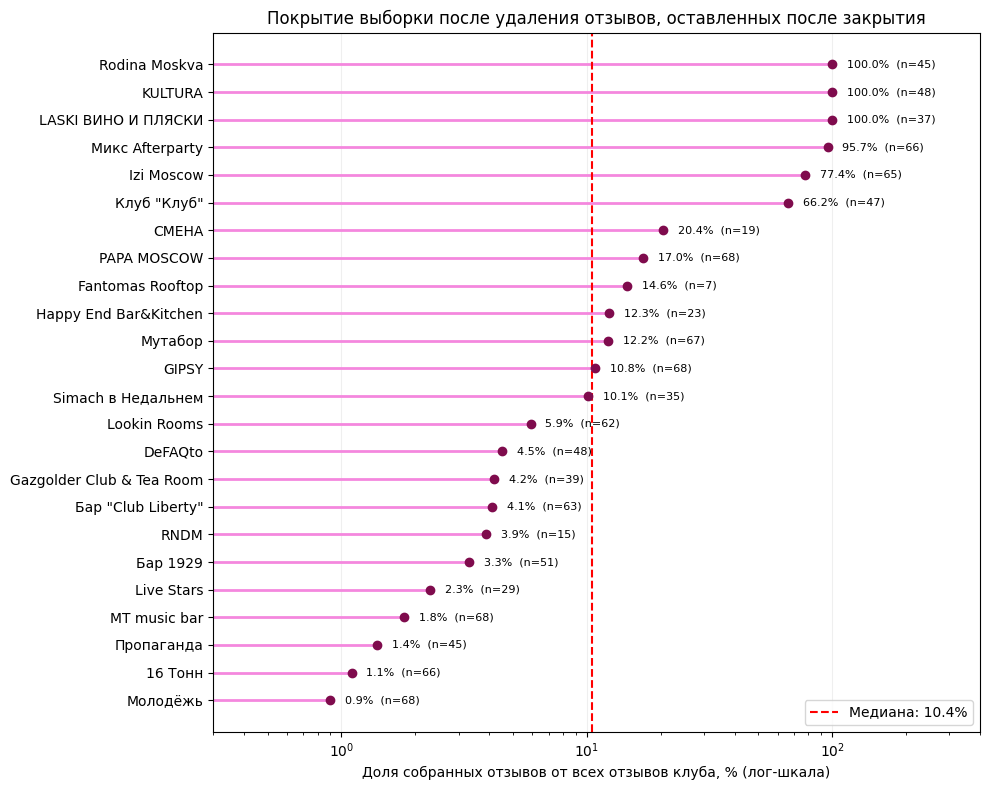

In [30]:
plot_df = coverage.sort_values('coverage_pct')

fig, ax = plt.subplots(figsize=(10, 8))
ax.hlines(plot_df.index, 0.3, plot_df['coverage_pct'], color="#F487DE", lw=2)
ax.scatter(plot_df['coverage_pct'], plot_df.index, color="#7F0B4D", zorder=3)

for club, row in plot_df.iterrows():
    ax.text(row['coverage_pct'] * 1.15, club,
            f"{row['coverage_pct']}%  (n={row['collected']})", va='center', fontsize=8)

median_coverage = plot_df['coverage_pct'].median()
ax.axvline(median_coverage, color='red', linestyle='--',
           label=f'Медиана: {median_coverage:.1f}%')

ax.set_xscale('log')
ax.set_xlim(0.3, 400)
ax.set_xlabel('Доля собранных отзывов от всех отзывов клуба, % (лог-шкала)')
ax.set_title('Покрытие выборки после удаления отзывов, оставленных после закрытия')
ax.grid(axis='x', alpha=0.2)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 3.5 Распределение оценок по всей выборке.

In [31]:
rating_distribution = (
    df_clean['rating']
    .value_counts()
    .reindex([1, 2, 3, 4, 5], fill_value=0)
    .rename_axis('rating')
    .reset_index(name='reviews_count')
)

rating_distribution['share_pct'] = (rating_distribution['reviews_count']/ len(df_clean) * 100).round(2)

rating_distribution

,rating,reviews_count,share_pct
0,1,331,28.81
1,2,33,2.87
2,3,38,3.31
3,4,63,5.48
4,5,684,59.53


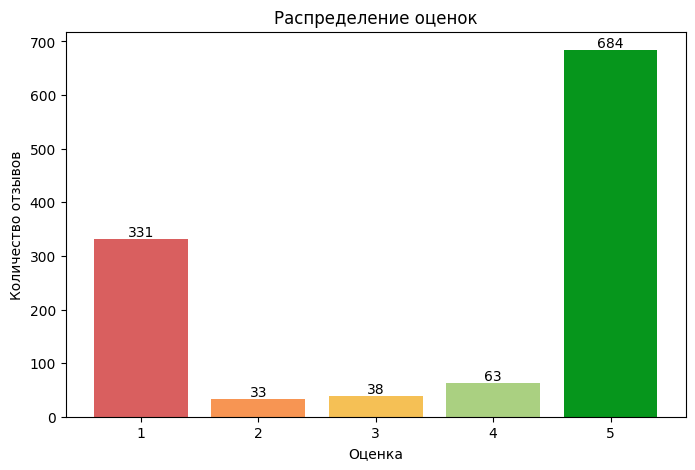

In [32]:
plt.figure(figsize=(8, 5))
colors = ['#d95f5f', "#f79553", "#f5c055", "#aad081", "#06961c"]
bars = plt.bar(
    rating_distribution['rating'],
    rating_distribution['reviews_count'],
    color=colors
)

plt.bar_label(bars)
plt.title('Распределение оценок')
plt.xlabel('Оценка')
plt.ylabel('Количество отзывов')
plt.xticks([1, 2, 3, 4, 5])
plt.show()

Распределение оценок поляризовано: большинство пользователей ставят либо 5, либо 1 звезду. Это может означать, что отзывы чаще оставляют гости с особенно положительным или негативным опытом.

In [33]:
df_clean['is_negative'] = df_clean['rating'] <= 2
print('Доля негативных отзывов во всей выборке:',
      round(df_clean['is_negative'].mean() * 100, 1), '%')

Доля негативных отзывов во всей выборке: 31.7 %


### 3.6 Доля негатива по клубам

Общая доля негатива может скрывать различия между заведениями. Поэтому рассчитаем ее по каждому клубу вместе с количеством отзывов, чтобы выявить потенциально проблемные клубы и определить, где улучшение клиентского опыта наиболее приоритетно.

In [34]:
negative_by_club = (
    df_clean
    .groupby('club')
    .agg(
        reviews_count=('rating', 'size'),
        negative_reviews=('is_negative', 'sum'),
        negative_share=('is_negative', 'mean')
    )
    .reset_index()
)

negative_by_club['negative_share_pct'] = (
    negative_by_club['negative_share'] * 100
).round(1)

negative_by_club = negative_by_club.sort_values(
    'negative_share_pct',
    ascending=False
)

negative_by_club[
    ['club', 'reviews_count', 'negative_reviews', 'negative_share_pct']
]

,club,reviews_count,negative_reviews,negative_share_pct
3,GIPSY,68,58,85.3
10,Lookin Rooms,62,52,83.9
23,СМЕНА,19,12,63.2
18,МТ music bar,68,33,48.5
2,Fantomas Rooftop,7,3,42.9
4,Gazgolder Club & Tea Room,39,16,41.0
22,Пропаганда,45,17,37.8
14,Simach в Недальнем,35,13,37.1
6,Izi Moscow,65,23,35.4
5,Happy End Bar&Kitchen,23,8,34.8


### Ограничение межклубного сравнения

Число отзывов по клубам различается в разы, поэтому доли негатива посчитаны с разной точностью. На графике ниже показаны все 24 заведения с 95%-ными доверительными интервалами Уилсона.

    Ограничение: Интервалы Уилсона показывают неопределенность долей в рамках биномиальной модели независимых наблюдений. Они не учитывают самоотбор авторов, различия периодов и возможную связь отзывов об одном событии. Поэтому график используется для описательного сравнения собранных отзывов. 

Для сравнения долей негатива выделяем клубы минимум с 30 собранными отзывами — этому условию соответствуют 19 из 24 заведений. На обзорном графике с интервалами Уилсона показываем все клубы, чтобы продемонстрировать различия в точности оценок. Для сравнения категорий жалоб применяем отдельный порог: минимум 30 текстовых отзывов — его проходят 15 клубов. В общем анализе тем сохраняются все 834 текстовых отзыва.

Классификатор применяется к отдельным отзывам и проверяется на ручной разметке. Поэтому отзывы клубов с небольшим числом наблюдений сохраняются в общем корпусе.


In [35]:
clubs_for_plot = (
    negative_by_club
    .query('reviews_count >= 30')
    .sort_values('negative_share_pct')
)
overall_negative_share = clubs_for_plot['negative_share_pct'].median()

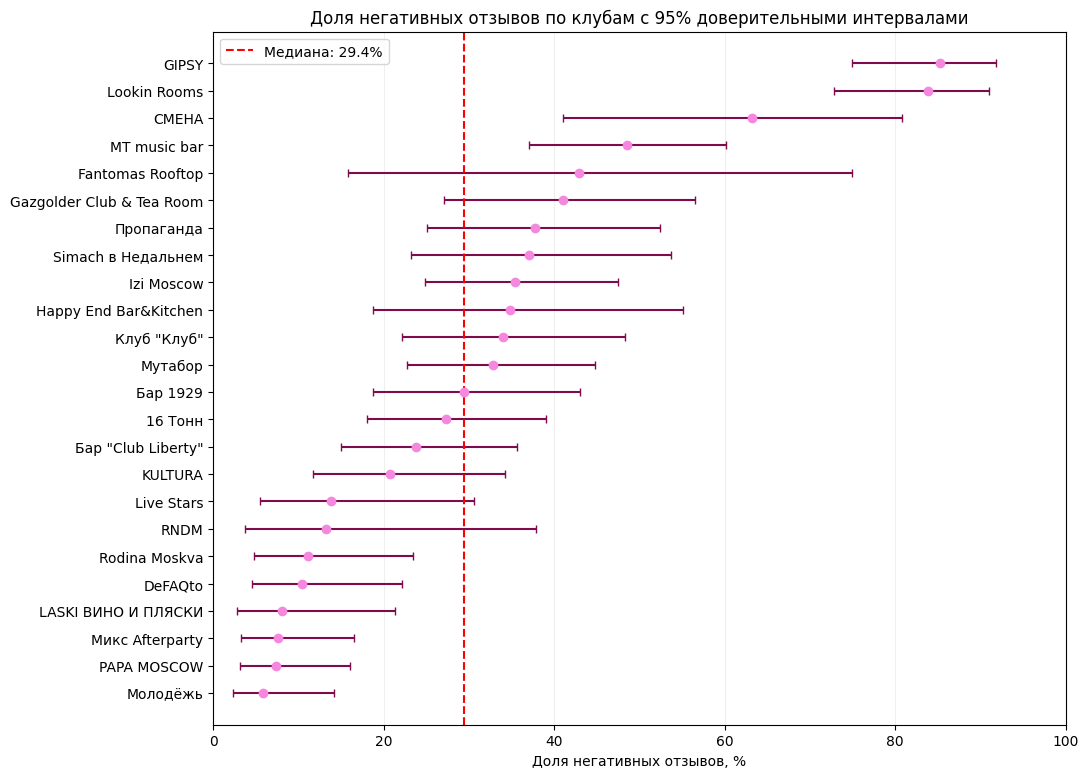

In [36]:
# Доверительный интервал Уилсона
confidence_intervals = negative_by_club.apply(
    lambda row: proportion_confint(
        count=row['negative_reviews'],
        nobs=row['reviews_count'],
        alpha=0.05,
        method='wilson'
    ),
    axis=1
)

negative_by_club[['ci_low', 'ci_high']] = pd.DataFrame(
    confidence_intervals.tolist(),
    index=negative_by_club.index
)

negative_by_club[['ci_low', 'ci_high']] *= 100

plot_df = negative_by_club.sort_values('negative_share_pct')

errors = np.array([
    plot_df['negative_share_pct'] - plot_df['ci_low'],
    plot_df['ci_high'] - plot_df['negative_share_pct']
])

fig, ax = plt.subplots(figsize=(11, 9))

ax.errorbar(
    x=plot_df['negative_share_pct'],
    y=plot_df['club'],
    xerr=errors,
    fmt='o',
    color="#F487DE",
    ecolor="#7F0B4D",
    capsize=3
)

ax.axvline(
    overall_negative_share,
    color='red',
    linestyle='--',
    label=f'Медиана: {overall_negative_share:.1f}%'
)

ax.set_xlim(0, 100)
ax.set_title('Доля негативных отзывов по клубам с 95% доверительными интервалами')
ax.set_xlabel('Доля негативных отзывов, %')
ax.set_ylabel('')
ax.grid(axis='x', alpha=0.2)
ax.legend()

plt.show()

Ниже приведены численные значения с графика:
- `reviews_count` — количество собранных отзывов;
- `negative_share_pct` — процент отзывов с оценкой 1–2;
- `ci_low` и `ci_high` — нижняя и верхняя границы 95%-ного
  доверительного интервала Уилсона, в процентах.

Чем шире интервал, тем менее точно оценена доля в рамках
принятой модели. Например, у Fantomas Rooftop всего 7 отзывов:
наблюдаемая доля негатива — 42,9%, а интервал — от 15,8% до 75,0%.
Поэтому сравнивать этот клуб с другими по одному проценту ненадёжно.

In [37]:
negative_by_club[
    ['club', 'reviews_count', 'negative_share_pct', 'ci_low', 'ci_high']
].round(1)

,club,reviews_count,negative_share_pct,ci_low,ci_high
3,GIPSY,68,85.3,75.0,91.8
10,Lookin Rooms,62,83.9,72.8,91.0
23,СМЕНА,19,63.2,41.0,80.9
18,МТ music bar,68,48.5,37.1,60.2
2,Fantomas Rooftop,7,42.9,15.8,75.0
4,Gazgolder Club & Tea Room,39,41.0,27.1,56.6
22,Пропаганда,45,37.8,25.1,52.4
14,Simach в Недальнем,35,37.1,23.2,53.7
6,Izi Moscow,65,35.4,24.9,47.5
5,Happy End Bar&Kitchen,23,34.8,18.8,55.1


### Выводы

- Среди 19 клубов с минимум 30 собранными отзывами доля оценок 1–2 звезды составляет от 5,9% до 85,3%, медиана — 29,4%.

- Наиболее высокие доли негатива наблюдаются у GIPSY — 85,3% и Lookin Rooms — 83,9%. Lookin Rooms представлен историческими отзывами до принятой даты закрытия.

- Клубы с близкими значениями не ранжируем: различия могут быть связаны с небольшим числом отзывов и особенностями выборки.

- Далее рассмотрим содержание текстовых отзывов, чтобы определить, на какие конкретно проблемы жалуются авторы.



### 3.7 Кто оставляет текст

Темы жалоб извлекаются только из текста, поэтому важно понять, чем текстовые отзывы отличаются от остальных. Предположение: недовольные гости пишут охотнее и подробнее, тогда как довольные ограничиваются оценкой.

Проверим две вещи: как часто текст вообще появляется при разных оценкахи насколько он длинный.

In [38]:
text_by_rating = (
    df_clean
    .assign(has_text=df_clean['text'].notna())
    .groupby('rating')
    .agg(
        reviews=('review_id', 'size'),
        with_text=('has_text', 'sum'),
        text_share=('has_text', 'mean')
    )
)

text_by_rating['text_share_pct'] = (
    text_by_rating['text_share'] * 100
).round(1)

text_by_rating

,reviews,with_text,text_share,text_share_pct
rating,,,,
1,331,252,0.761329,76.1
2,33,25,0.757576,75.8
3,38,31,0.815789,81.6
4,63,43,0.682540,68.3
5,684,483,0.706140,70.6


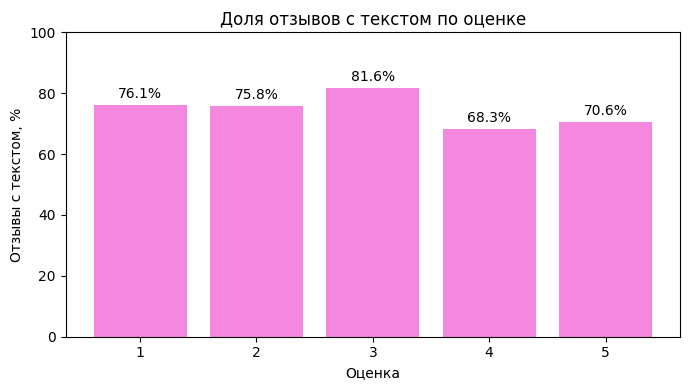

In [39]:

fig, ax = plt.subplots(figsize=(7, 4))

bars = ax.bar(
    text_by_rating.index,
    text_by_rating['text_share_pct'],
    color="#F487DE"
)

ax.bar_label(bars, fmt='%.1f%%', padding=3)

ax.set_ylim(0, 100)
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_xlabel('Оценка')
ax.set_ylabel('Отзывы с текстом, %')
ax.set_title('Доля отзывов с текстом по оценке')

plt.tight_layout()
plt.show()

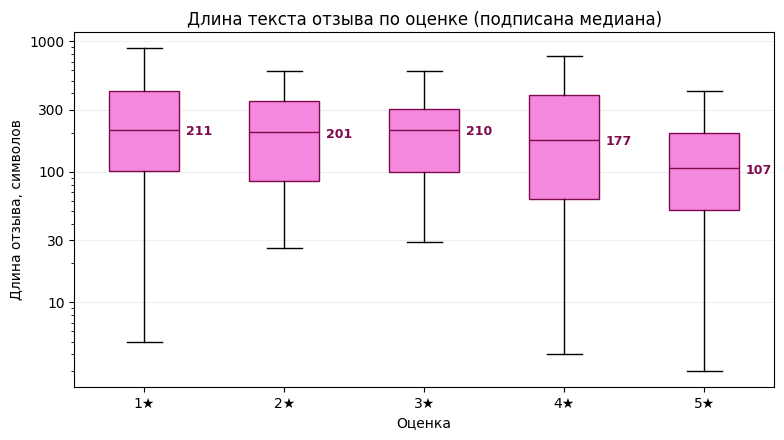

In [40]:
import matplotlib.ticker

df_nlp['text_length'] = df_nlp['text'].str.len()

fig, ax = plt.subplots(figsize=(8, 4.5))
data = [df_nlp[df_nlp['rating'] == r]['text_length'] for r in [1, 2, 3, 4, 5]]

bp = ax.boxplot(data, tick_labels=['1★', '2★', '3★', '4★', '5★'],
                patch_artist=True, showfliers=False)
for box in bp['boxes']:
    box.set_facecolor("#F487DE")
    box.set_edgecolor("#7F0B4D")
for med in bp['medians']:
    med.set_color("#7F0B4D")
    med.set_linewidth(1)

for i, values in enumerate(data, start=1):
    median_value = values.median()
    ax.annotate(f'{median_value:.0f}', (i, median_value),
                xytext=(30, -4), textcoords='offset points',
                fontsize=9, color="#7F0B4D", fontweight='bold')

ax.set_yscale('log')
ax.set_yticks([10, 30, 100, 300, 1000])
ax.get_yaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
ax.set_ylabel('Длина отзыва, символов')
ax.set_xlabel('Оценка')
ax.set_title('Длина текста отзыва по оценке (подписана медиана)')
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

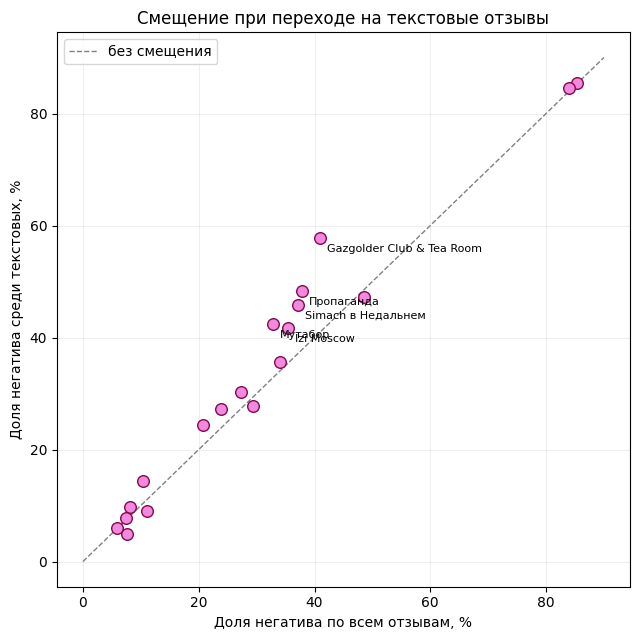

In [41]:
text_bias = pd.DataFrame({
    'neg_all':  df_clean.groupby('club')['is_negative'].mean() * 100,
    'neg_text': df_nlp.assign(is_negative=df_nlp['rating'] <= 2)
                      .groupby('club')['is_negative'].mean() * 100,
    'n': df_clean.groupby('club').size()
}).query('n >= 30').round(1)
text_bias['diff'] = (text_bias['neg_text'] - text_bias['neg_all']).round(1)

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.scatter(text_bias['neg_all'], text_bias['neg_text'], s=70,
           color="#F487DE", edgecolor="#7F0B4D", zorder=3)
ax.plot([0, 90], [0, 90], color='grey', linestyle='--', lw=1, label='без смещения')

for club, row in text_bias.iterrows():
    if abs(row['diff']) >= 6:
        ax.annotate(club, (row['neg_all'], row['neg_text']),
                    xytext=(5, -10), textcoords='offset points', fontsize=8)

ax.set_xlabel('Доля негатива по всем отзывам, %')
ax.set_ylabel('Доля негатива среди текстовых, %')
ax.set_title('Смещение при переходе на текстовые отзывы')
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### Выводы:

Наличие текста почти не зависит от оценки: у единиц текст есть в 76% случаев, у пятёрок — в 71%. А вот длина различается вдвое: медиана 211 символов у оценки 1 против 107 у оценки 5. Оценки 2–4 ведут себя как негативные.
В собранной выборке текст присутствует у 76,1% отзывов с оценкой 1 и у 70,6% отзывов с оценкой 5 — разница по частоте небольшая. Различается длина: медиана 211 символов у единиц против 107 у пятерок. Оценки 2–4 по длине текста ведут себя ближе к негативным.

Это различие можно объяснить тем, что пятерка обычно исчерпывается одним словом, а единица требует объяснения. Однако более длинные тексты у негативных отзывов не означают, что положительные обязательно короткие или неинформативные, потому что само это различие не измеряет информативность текста. Правило разметки «единица размечается только если это жалоба» опирается на задачу проекта (искать жалобы), а не на длину положительных отзывов.

### 3.8 `club_rating` против средней по выборке.

In [42]:
rating_gap = (
    df_clean.groupby('club')
    .agg(n=('rating', 'size'),
         sample_mean=('rating', 'mean'),
         club_rating=('club_rating', 'first'),
         total=('club_reviews_total', 'first'))
    .query('n >= 30')
)
rating_gap['coverage'] = (rating_gap['n'] / rating_gap['total'] * 100).round(1)
rating_gap['gap'] = (rating_gap['sample_mean'] - rating_gap['club_rating']).round(2)
rating_gap['sample_mean'] = rating_gap['sample_mean'].round(2)

rating_gap.sort_values('gap')

,n,sample_mean,club_rating,total,coverage,gap
club,,,,,,
Lookin Rooms,62,1.63,3.9,1059,5.9,-2.27
GIPSY,68,1.59,3.4,628,10.8,-1.81
МТ music bar,68,2.97,4.4,3754,1.8,-1.43
Gazgolder Club & Tea Room,39,3.18,4.4,939,4.2,-1.22
Simach в Недальнем,35,3.34,4.3,345,10.1,-0.96
Пропаганда,45,3.36,4.3,3226,1.4,-0.94
Мутабор,67,3.45,4.3,548,12.2,-0.85
16 Тонн,66,3.68,4.5,5904,1.1,-0.82
"Бар ""Club Liberty""",63,3.81,4.3,1544,4.1,-0.49


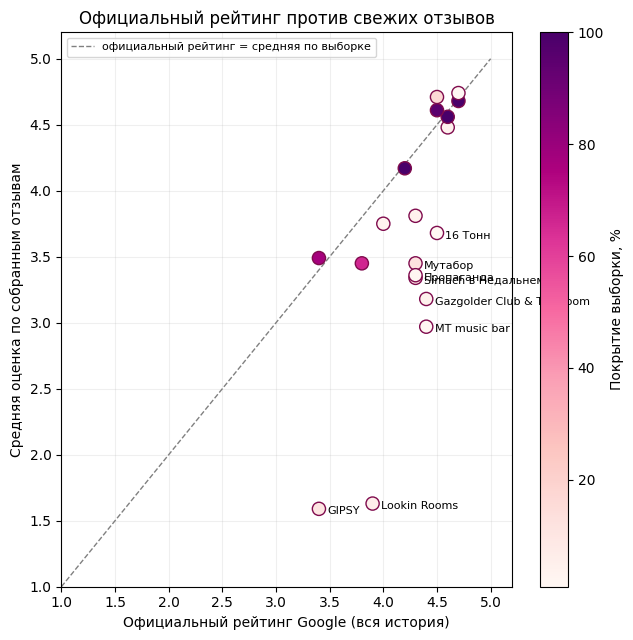

In [43]:
fig, ax = plt.subplots(figsize=(6.5, 6.5))

sc = ax.scatter(rating_gap['club_rating'], rating_gap['sample_mean'],
                c=rating_gap['coverage'], cmap='RdPu', s=90,
                edgecolor="#7F0B4D", zorder=3)
ax.plot([1, 5], [1, 5], color='grey', linestyle='--', lw=1,
        label='официальный рейтинг = средняя по выборке')

for club, row in rating_gap.iterrows():
    if abs(row['gap']) >= 0.8:
        ax.annotate(club, (row['club_rating'], row['sample_mean']),
                    xytext=(6, -4), textcoords='offset points', fontsize=8)

plt.colorbar(sc, ax=ax, label='Покрытие выборки, %')
ax.set_xlim(1, 5.2)
ax.set_ylim(1, 5.2)
ax.set_xlabel('Официальный рейтинг Google (вся история)')
ax.set_ylabel('Средняя оценка по собранным отзывам')
ax.set_title('Официальный рейтинг против свежих отзывов')
ax.legend(loc='upper left', fontsize=8)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### Зависимая переменная и период наблюдения

Доли тем считаются по собранным отзывам, а рейтинг заведения накоплен за всю
его историю. Это разные периоды, и величину расхождения нужно измерить.

Средняя оценка по выборке ниже официального рейтинга на 0,59 звезды: у 15
из 19 клубов свежие отзывы хуже накопленной оценки. Расхождение достигает
2,27 звезды у Lookin Rooms и 1,81 у GIPSY. Корреляция между двумя величинами
составляет 0,70 — порядок заведений сохраняется, но уровень сдвинут.

Величина разрыва связана с покрытием выборки (корреляция 0,54). У трёх клубов
со 100%-ным покрытием он практически нулевой: собранные отзывы и есть весь
рейтинг. Чем меньшую долю истории удалось собрать, тем сильнее расхождение.

Официальный рейтинг Google и средняя оценка собранных отзывов относятся к разным совокупностям и периодам. Поэтому далее для характеристики отзывов с жалобами используется их собственная звездная оценка. club_rating остется справочной характеристикой заведения

### 3.9 Распределение club_rating

In [44]:
# Оставляем по одной строке на клуб
club_ratings = (
    df_clean[['club', 'club_rating']]
    .drop_duplicates(subset='club')
)

club_ratings['club_rating'].describe()

count    24.000000
mean      4.208333
std       0.398821
min       3.400000
25%       4.000000
50%       4.300000
75%       4.500000
max       4.700000
Name: club_rating, dtype: float64

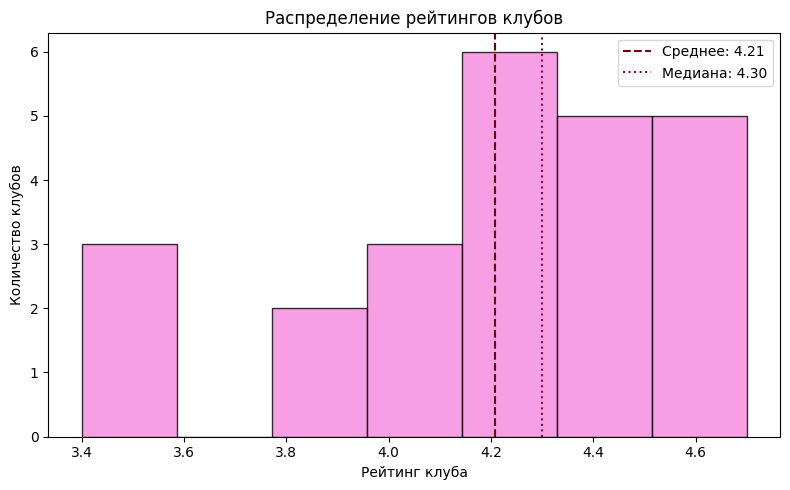

In [45]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    club_ratings['club_rating'],
    bins=7,
    edgecolor='black',
    alpha=0.8,
    color = "#F487DE"
)

ax.axvline(
    club_ratings['club_rating'].mean(),
    linestyle='--',
    label=f"Среднее: {club_ratings['club_rating'].mean():.2f}",
    color="#6B0508"
)

ax.axvline(
    club_ratings['club_rating'].median(),
    linestyle=':',
    label=f"Медиана: {club_ratings['club_rating'].median():.2f}",
    color="#7F0B4D"
)

ax.set_xlabel('Рейтинг клуба')
ax.set_ylabel('Количество клубов')
ax.set_title('Распределение рейтингов клубов')

ax.legend()

plt.tight_layout()
plt.show()

Рейтинги большинства клубов сосредоточены в диапазоне 4.0–4.7. Средний рейтинг составляет 4.21, медианный — 4.30. Среднее ниже медианы из-за нескольких заведений с заметно более низкими рейтингами около 3.4–3.5. Таким образом, распределение имеет небольшой левый хвост, при этом основная часть клубов имеет достаточно высокие оценки.

# 4. NLP с подключением LLM

### 4.1 Подключение GENAI
Для автоматической классификации отзывов используется PROXY API.  
API-ключ хранится в `.env` и не включается в репозиторий.

##### Подключаем модель gemini-2.5-flash через API:

In [46]:
import os
import json

from dotenv import load_dotenv
from openai import OpenAI

load_dotenv()

PROXYAPI_KEY = os.getenv('PROXYAPI_KEY')

client = OpenAI(
    api_key=PROXYAPI_KEY,
    base_url='https://api.proxyapi.ru/v1'
)

MODEL = 'google/gemini-2.5-flash'

### 4.2 Тест классификатора на одном отзыве c GEMINI 2.5 

##### Проводим тест на 1 отзыве:

In [47]:
#читаем промпт
with open('src/prompt.txt', 'r', encoding='utf-8') as f:
    SYSTEM_PROMPT = f.read()

In [48]:
test_review = """
Музыка отличная и сам клуб красивый, но охрана на входе разговаривала
очень грубо и без причины долго не хотела нас пускать.
"""

In [49]:
response = client.chat.completions.create(
    model=MODEL,
    messages=[
        {
            'role': 'system',
            'content': SYSTEM_PROMPT
        },
        {
            'role': 'user',
            'content': test_review
        }
    ],
    temperature=0,
    reasoning_effort='none',
    response_format={'type': 'json_object'}
)

result = json.loads(response.choices[0].message.content)

result

{'entry_security': 1,
 'music_sound': 0,
 'staff_service': 0,
 'bar_food': 0,
 'venue_comfort': 0,
 'prices_finance': 0,
 'paid_entry': 0,
 'safety_theft': 0,
 'crowd': 0,
 'other': 0}

In [50]:
print('Input tokens:', response.usage.prompt_tokens)
print('Output tokens:', response.usage.completion_tokens)
print('Total tokens:', response.usage.total_tokens)

Input tokens: 2717
Output tokens: 100
Total tokens: 2817


### 4.3 Валидация LLM-классификатора

Для автоматической multi-label классификации используется Gemini 2.5 Flash через ProxyAPI. Модель получает фиксированный system prompt и текст одного отзыва и возвращает бинарные метки категорий жалоб. Один отзыв может относиться к нескольким категориям.

Обучение или дообучение модели не проводится. Prompting позволяет разметить небольшой корпус без подготовки большого обучающего набора.

Качество классификации проверяется на 149 вручную размеченных отзывах, отобранных со стратификацией по звёздной оценке. Для каждой категории рассчитываются precision, recall и F1.

### Категории жалоб

Модель отмечает категорию, только если автор выражает недовольство. Похвала и нейтральное упоминание не считаются жалобой. Один отзыв может содержать несколько категорий.

| Категория | Какие жалобы сюда относятся |
|---|---|
| Вход / фейсконтроль / охрана | Отказ во входе, непонятные правила допуска, грубость охраны, досмотр, очередь на вход |
| Музыка / звук | Подбор музыки, работа DJ, качество и громкость звука |
| Персонал / сервис | Грубость, медленное обслуживание, ошибки и отказ помочь со стороны персонала, кроме охраны |
| Бар / еда | Плохое качество еды и напитков, разбавленный алкоголь, отсутствие нужных позиций |
| Помещение / комфорт | Теснота, духота, грязь, туалеты, гардероб, нехватка мест и очереди внутри, связанные с инфраструктурой |
| Цены / финансовые вопросы | Высокие цены, ошибки в счёте, дополнительные платежи, проблемы с возвратом денег |
| Платный вход | Дорогой или неожиданно платный вход, платный VIP-проход, депозит как условие допуска |
| Безопасность / кражи | Кражи, опасные ситуации, угрозы посетителям или их имуществу |
| Контингент | Недовольство поведением или составом публики |
| Прочее | Другие конкретные жалобы, например задержка концерта |

Категории могут пересекаться. Например:
- слишком дорогой вход — «Платный вход» и «Цены / финансовые вопросы»;
- медленное обслуживание и плохой коктейль — «Персонал / сервис» и «Бар / еда».

Общее недовольство без конкретной проблемы не относится автоматически к категории «Прочее».

In [51]:
import time
import json
import pandas as pd


def classify_review(text, max_retries=3):

    for attempt in range(max_retries):

        try:
            response = client.chat.completions.create(
                model=MODEL,
                messages=[
                    {
                        'role': 'system',
                        'content': SYSTEM_PROMPT
                    },
                    {
                        'role': 'user',
                        'content': str(text)
                    }
                ],
                temperature=0,
                reasoning_effort='none',
                response_format={'type': 'json_object'}
            )

            return json.loads(
                response.choices[0].message.content
            )

        except Exception as e:
            print(
                f'Ошибка, попытка {attempt + 1}/{max_retries}: {e}'
            )

            if attempt < max_retries - 1:
                time.sleep(3)

    return None

In [52]:
gold = pd.read_excel(
    'data/benchmark1.xlsx',
    sheet_name='разметка',
    header=1
)

print(gold.shape)

(149, 16)


In [53]:
label_mapping = {
    'entry_security': 'вход_фейсконтроль_охрана',
    'music_sound': 'музыка_звук',
    'staff_service': 'персонал_сервис',
    'bar_food': 'бар_еда',
    'venue_comfort': 'помещение_комфорт',
    'prices_finance': 'цены_финвопросы',
    'paid_entry': 'платный_вход',
    'safety_theft': 'безопасность_кражи',
    'crowd': 'контингент',
    'other': 'прочее'
}

In [54]:
gold.columns.tolist()

['review_id',
 'club',
 'rating',
 'date_iso',
 'text',
 'вход_фейсконтроль_охрана',
 'Unnamed: 6',
 'музыка_звук',
 'персонал_сервис',
 'бар_еда',
 'помещение_комфорт',
 'цены_финвопросы',
 'платный_вход',
 'безопасность_кражи',
 'прочее',
 'контингент']

In [55]:
checkpoint_file = 'data/proxyapi_benchmark_pred1.csv'

if os.path.exists(checkpoint_file):
    saved = pd.read_csv(checkpoint_file)
    processed_ids = set(saved['review_id'])
    print('Уже обработано:', len(saved))
else:
    saved = pd.DataFrame()
    processed_ids = set()

results = []

for i, row in gold.iterrows():

    if row['review_id'] in processed_ids:
        continue

    print(f'{i + 1}/{len(gold)}', end='\r')

    prediction = classify_review(row['text'])

    if prediction is None:
        print(f'\nНе удалось обработать строку {i}')
        continue

    result_row = {
        'review_id': row['review_id'],
        'text': row['text']
    }

    for model_label, gold_label in label_mapping.items():
        result_row[f'gold_{gold_label}'] = row[gold_label]
        result_row[f'pred_{gold_label}'] = prediction[model_label]

    results.append(result_row)

new_df = pd.DataFrame(results)
checkpoint = pd.concat([saved, new_df], ignore_index=True) if len(saved) else new_df
checkpoint = checkpoint.drop_duplicates(subset='review_id', keep='last')
checkpoint.to_csv(checkpoint_file, index=False, encoding='utf-8-sig')

print('Готово')

Уже обработано: 149
Готово


### 4.4 Оценка качества классификации

Предсказания LLM сравниваются с ручной разметкой эталонной выборки.

Для каждой темы рассчитываются:
- **precision** — доля правильных срабатываний среди всех срабатываний модели;
- **recall** — доля найденных моделью жалоб среди всех реально размеченных жалоб;
- **F1-score** — гармоническое среднее precision и recall.

`support` показывает количество положительных примеров каждой темы в ручной разметке.

Micro F1 рассчитывается по суммарным TP, FP и FN всех категорий. Macro F1 — среднее F1 по категориям с одинаковым весом каждой. F1 оценивает, насколько хорошо модель находит категории жалоб. Он не показывает процент полностью правильно размеченных отзывов.

In [56]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
)

gold_cols = list(label_mapping.values())
pred_cols = [f'pred_{col}' for col in gold_cols]

predictions = pd.read_csv('data/proxyapi_benchmark_pred1.csv')

for frame in (gold, predictions):
    assert frame['review_id'].notna().all()
    assert frame['review_id'].is_unique

assert set(gold['review_id']) == set(predictions['review_id']), (
    'Состав benchmark и предсказаний не совпадает'
)

evaluation = gold.merge(
    predictions[['review_id'] + pred_cols],
    on='review_id',
    how='left',
    validate='one_to_one',
)

assert evaluation[gold_cols + pred_cols].isin([0, 1]).all().all(), (
    'В разметке есть пропуски или значения, отличные от 0/1'
)

metrics = []

for col in gold_cols:
    y_true = evaluation[col].astype(int)
    y_pred = evaluation[f'pred_{col}'].astype(int)

    metrics.append({
        'topic': col,
        'support': int(y_true.sum()),
        'predicted_positive': int(y_pred.sum()),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
    })

metrics_df = pd.DataFrame(metrics)
display(metrics_df.round(3))

y_true = evaluation[gold_cols].to_numpy(dtype=int)
y_pred = evaluation[pred_cols].to_numpy(dtype=int)

for average in ('micro', 'macro'):
    score = f1_score(
        y_true, y_pred,
        average=average,
        zero_division=0,
    )
    print(f'{average.capitalize()} F1: {score:.3f}')

,topic,support,predicted_positive,precision,recall,f1
0,вход_фейсконтроль_охрана,25,26,0.885,0.920,0.902
1,музыка_звук,4,5,0.800,1.000,0.889
2,персонал_сервис,18,18,0.778,0.778,0.778
3,бар_еда,8,13,0.615,1.000,0.762
4,помещение_комфорт,12,16,0.625,0.833,0.714
5,цены_финвопросы,15,17,0.824,0.933,0.875
6,платный_вход,5,7,0.571,0.800,0.667
7,безопасность_кражи,1,3,0.333,1.000,0.500
8,контингент,4,6,0.667,1.000,0.800
9,прочее,7,7,0.571,0.571,0.571


Micro F1: 0.793
Macro F1: 0.746


#### Вывод

Модель показала Micro F1 = 0,793 и Macro F1 = 0,746.

Для основной категории — входа и фейсконтроля — F1 составил 0,902 при 25 примерах жалоб в ручной разметке.

Для музыки F1 тоже высокий — 0,889, но проверка включала всего четыре примера таких жалоб. Этого мало для уверенного вывода о качестве. Для безопасности был только один положительный пример, поэтому её метрики особенно ненадёжны.

В категориях бара, помещения и платного входа модель нередко отмечала жалобы там, где ручная разметка их не содержала. Поэтому дальше нужно учитывать, что количество жалоб по этим темам может быть завышено.

Полученное качество считаем достаточным для дальнейшей exploratory-разметки полного корпуса отзывов.

### 4.5 Разметка полного корпуса отзывов

После валидации классификатор применяется ко всем отзывам с текстом.

Для каждого отзыва модель определяет наличие жалоб по зафиксированной таксоном

In [57]:
print('Отзывов для классификации:', len(df_nlp))
print('Уникальных review_id:', df_nlp['review_id'].nunique())

Отзывов для классификации: 834
Уникальных review_id: 834


In [58]:
import os
import time
import pandas as pd

checkpoint_file = 'data/full_reviews_predictions.csv'

# если запуск уже был, подхватываем сохраненное
if os.path.exists(checkpoint_file):
    saved = pd.read_csv(checkpoint_file)
    processed_ids = set(saved['review_id'])

    print('Уже обработано:', len(saved))
else:
    saved = pd.DataFrame()
    processed_ids = set()

results = []

for n, (_, row) in enumerate(df_nlp.iterrows(), start=1):

    # уже обработанные отзывы не отправляем повторно
    if row['review_id'] in processed_ids:
        continue

    print(
        f'{len(processed_ids) + len(results) + 1}/{len(df_nlp)}',
        end='\r'
    )

    prediction = classify_review(row['text'])

    if prediction is None:
        print(f"\nОшибка на review_id: {row['review_id']}")
        continue

    result_row = {
        'review_id': row['review_id']
    }

    # label_mapping уже содержит соответствие
    for model_label, label in label_mapping.items():
        result_row[f'pred_{label}'] = prediction[model_label]

    results.append(result_row)

    # сохраняем каждые 10 новых отзывов
    if len(results) % 10 == 0:

        new_df = pd.DataFrame(results)

        if len(saved) > 0:
            checkpoint = pd.concat(
                [saved, new_df],
                ignore_index=True
            )
        else:
            checkpoint = new_df

        checkpoint.to_csv(
            checkpoint_file,
            index=False,
            encoding='utf-8-sig'
        )

# сохраняем остаток
new_df = pd.DataFrame(results)

if len(saved) > 0:
    checkpoint = pd.concat(
        [saved, new_df],
        ignore_index=True
    )
else:
    checkpoint = new_df

checkpoint = checkpoint.drop_duplicates(
    subset='review_id',
    keep='last'
)

checkpoint.to_csv(
    checkpoint_file,
    index=False,
    encoding='utf-8-sig'
)

print('\nГотово')
print('Классифицировано:', len(checkpoint))

Уже обработано: 834

Готово
Классифицировано: 834


In [59]:
full_predictions = pd.read_csv(
    'data/full_reviews_predictions.csv'
)

print('Нужно:', len(df_nlp))
print('Получено:', len(full_predictions))
print('Пропущено:', len(df_nlp) - len(full_predictions))

Нужно: 834
Получено: 834
Пропущено: 0


# 5. Анализ результатов

### 5.1 Формирование итогового размеченного датасета
После завершения LLM-разметки полученные предсказания объединяются с исходными текстами отзывов по `review_id`. Дополнительно проверяется, что после объединения не появились дубли и пропущенные значения в колонках с предсказаниями.

In [60]:
#соединяем текстовые отзывы с полученными значеними
df_labeled = df_nlp.merge(
    full_predictions,
    on='review_id',
    how='left',
    validate='one_to_one'
)

print(df_labeled.shape)

(834, 19)


In [61]:
pred_cols = [
    col for col in df_labeled.columns
    if col.startswith('pred_')
]

df_labeled[pred_cols].isna().sum()

pred_вход_фейсконтроль_охрана    0
pred_музыка_звук                 0
pred_персонал_сервис             0
pred_бар_еда                     0
pred_помещение_комфорт           0
pred_цены_финвопросы             0
pred_платный_вход                0
pred_безопасность_кражи          0
pred_контингент                  0
pred_прочее                      0
dtype: int64

In [62]:
assert df_labeled[pred_cols].isin([0, 1]).all().all(), (
    'В разметке есть пропуски или значения, отличные от 0 и 1'
)

print('Проверка пройдена: все категории заполнены значениями 0 или 1')

Проверка пройдена: все категории заполнены значениями 0 или 1


In [63]:
#сохраняем новую таблицу
df_labeled.to_csv(
    'data/club_reviews_labeled.csv',
    index=False,
    encoding='utf-8-sig'
)

### 5.2 Описательный анализ жалоб

##### Частота жалоб по категориям

In [64]:
#Частота жалоб по категориям
complaint_frequency = (
    df_labeled[pred_cols]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

complaint_frequency.columns = ['complaint', 'reviews_count']

complaint_frequency['share_pct'] = (
    complaint_frequency['reviews_count'] / len(df_labeled) * 100
)

complaint_frequency

,complaint,reviews_count,share_pct
0,pred_вход_фейсконтроль_охрана,144,17.266187
1,pred_персонал_сервис,97,11.630695
2,pred_помещение_комфорт,80,9.592326
3,pred_цены_финвопросы,80,9.592326
4,pred_бар_еда,68,8.153477
5,pred_прочее,45,5.395683
6,pred_музыка_звук,38,4.556355
7,pred_контингент,28,3.357314
8,pred_платный_вход,23,2.757794
9,pred_безопасность_кражи,13,1.558753


##### Количество жалоб в одном отзыве

In [65]:
df_labeled['complaints_count'] = df_labeled[pred_cols].sum(axis=1)

print(
    df_labeled['complaints_count']
    .value_counts()
    .sort_index()
)

print(
    '\nДоля отзывов хотя бы с одной жалобой:',
    (df_labeled['complaints_count'] > 0).mean() * 100
)

complaints_count
0    492
1    179
2     90
3     48
4     14
5      9
6      2
Name: count, dtype: int64

Доля отзывов хотя бы с одной жалобой: 41.007194244604314


##### Средняя оценка отзывов по категориям жалоб

In [66]:
theme_rating = []

for col in pred_cols:
    mean_rating = df_labeled.loc[
        df_labeled[col] == 1,
        'rating'
    ].mean()

    theme_rating.append({
        'complaint': col,
        'mean_rating': mean_rating
    })

theme_rating = (
    pd.DataFrame(theme_rating)
    .sort_values('mean_rating')
)

theme_rating = (
    pd.DataFrame(theme_rating)
    .sort_values('mean_rating')
)

theme_rating

,complaint,mean_rating
0,pred_вход_фейсконтроль_охрана,1.173611
6,pred_платный_вход,1.434783
7,pred_безопасность_кражи,1.461538
2,pred_персонал_сервис,1.608247
9,pred_прочее,1.644444
8,pred_контингент,1.678571
5,pred_цены_финвопросы,1.750000
1,pred_музыка_звук,1.973684
3,pred_бар_еда,2.161765
4,pred_помещение_комфорт,2.512500


### Сравнение средних оценок

В этой выборке отзывы с жалобами на вход сопровождаются наиболее низкой средней оценкой — 1,17 звезды. Для платного входа и безопасности средние составляют 1,43 и 1,46, однако эти категории представлены небольшим числом отзывов. Различия между средними не показывают, насколько исправление каждой проблемы изменит рейтинг: один отзыв может содержать несколько жалоб.

### 5.3 Приоритизация жалоб по частоте и индексу тяжести


In [67]:
priority_table = (
    complaint_frequency
    .merge(
        theme_rating,
        on='complaint',
        how='inner',
        validate='one_to_one'
    )
)

priority_table['severity'] = 5 - priority_table['mean_rating']

priority_table['complaint'] = (
    priority_table['complaint']
    .str.replace('pred_', '', regex=False)
)

priority_table = priority_table.sort_values(
    'share_pct',
    ascending=False
)

priority_table

,complaint,reviews_count,share_pct,mean_rating,severity
0,вход_фейсконтроль_охрана,144,17.266187,1.173611,3.826389
1,персонал_сервис,97,11.630695,1.608247,3.391753
2,помещение_комфорт,80,9.592326,2.512500,2.487500
3,цены_финвопросы,80,9.592326,1.750000,3.250000
4,бар_еда,68,8.153477,2.161765,2.838235
5,прочее,45,5.395683,1.644444,3.355556
6,музыка_звук,38,4.556355,1.973684,3.026316
7,контингент,28,3.357314,1.678571,3.321429
8,платный_вход,23,2.757794,1.434783,3.565217
9,безопасность_кражи,13,1.558753,1.461538,3.538462


Для приоритизации проблем используются два показателя:

- **частота** — доля отзывов, в которых встречается соответствующая жалоба;
- **индекс тяжести** — `5 − средняя оценка` среди отзывов с данной жалобой. Чем ниже оценки пользователей при упоминании проблемы, тем выше индекс тяжести.

Пунктирные линии соответствуют медианным значениям частоты и тяжести и разделяют жалобы на четыре относительные группы. Наибольший интерес с точки зрения приоритизации представляет правый верхний квадрант — проблемы, которые одновременно встречаются часто и сопровождаются наиболее низкими пользовательскими оценками.

In [68]:
label_names = {
    'вход_фейсконтроль_охрана': 'Вход / фейсконтроль / охрана',
    'персонал_сервис': 'Персонал / сервис',
    'цены_финвопросы': 'Цены/ финансовые вопросы',
    'помещение_комфорт': 'Помещение / комфорт',
    'бар_еда': 'Бар / еда',
    'музыка_звук': 'Музыка / звук',
    'контингент': 'Контингент',
    'платный_вход': 'Платный вход',
    'безопасность_кражи': 'Безопасность / кражи'
}

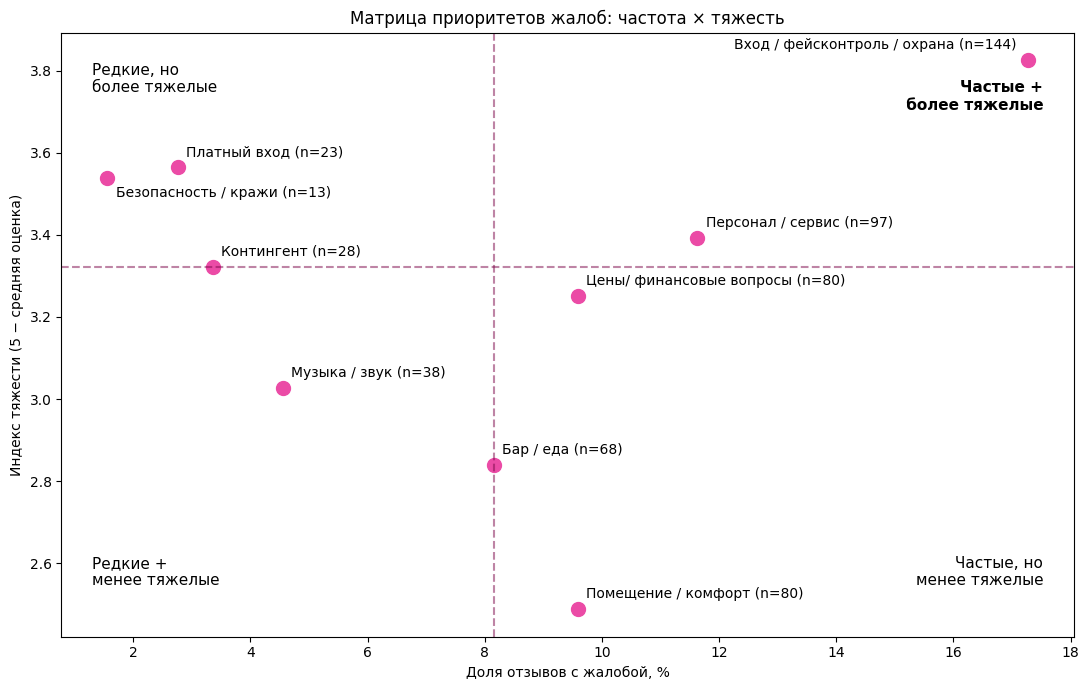

In [69]:
plot_df = priority_table[
    priority_table['complaint'] != 'прочее'
].copy()

x_median = plot_df['share_pct'].median()
y_median = plot_df['severity'].median()

fig, ax = plt.subplots(figsize=(11, 7))

ax.scatter(
    plot_df['share_pct'],
    plot_df['severity'],
    color="#EB4BA6",
    s=100
)


for _, row in plot_df.iterrows():

    label = label_names.get(
        row['complaint'],
        row['complaint']
    )

    # Для редких категорий показываем размер группы
    if row['reviews_count'] :
        label += f" (n={int(row['reviews_count'])})"

    # значения по умолчанию
    xytext = (6, 6)
    ha = 'left'
    va = 'bottom'

    # отдельное расположение длинных / пересекающихся подписей
    if row['complaint'] == 'вход_фейсконтроль_охрана':
        xytext = (-8, 6)
        ha = 'right'

    elif row['complaint'] == 'безопасность_кражи':
        xytext = (6, -6)
        va = 'top'

    ax.annotate(
        label,
        (row['share_pct'], row['severity']),
        xytext=xytext,
        textcoords='offset points',
        ha=ha,
        va=va,
        fontsize=10
    )

# Медианные границы квадрантов
ax.axvline(x_median, color="#7F0B4D", linestyle='--', alpha=0.5)
ax.axhline(y_median,color="#7F0B4D", linestyle='--', alpha=0.5)
# Подписи квадрантов
ax.text(
    0.03, 0.95,
    'Редкие, но\nболее тяжелые',
    transform=ax.transAxes,
    va='top',
    fontsize=11
)

ax.text(
    0.97, 0.95,
    '\nЧастые +\n более тяжелые',
    transform=ax.transAxes,
    va='top',
    ha='right',
    fontsize=11,
    fontweight='bold'
)

ax.text(
    0.03, 0.08,
    'Редкие +\nменее тяжелые',
    transform=ax.transAxes,
    va='bottom',
    fontsize=11
)

ax.text(
    0.97, 0.08,
    'Частые, но\nменее тяжелые',
    transform=ax.transAxes,
    va='bottom',
    ha='right',
    fontsize=11
)

ax.set_xlabel('Доля отзывов с жалобой, %')
ax.set_ylabel('Индекс тяжести (5 − средняя оценка)')
ax.set_title('Матрица приоритетов жалоб: частота × тяжесть')

plt.tight_layout()
plt.show()

Пунктирные линии соответствуют медианным значениям частоты и индекса тяжести и используются для относительного разделения категорий жалоб.

Размер групп различается (`n = от 13 до 144`), поэтому оценки индекса тяжести для редких категорий менее устойчивы, поэтому размер выборки указан непосредственно на графике.

Индекс тяжести отражает среднюю оценку отзывов, в которых присутствует соответствующая тема, и не является оценкой причинного эффекта отдельной жалобы. Поскольку один отзыв может содержать несколько категорий жалоб, оценки по темам частично пересекаются.

### 5.4 Сравнение профиля жалоб между клубами
Чтобы проверить, являются ли выявленные проблемы общими для рынка или концентрируются в отдельных заведениях, для каждого клуба рассчитана доля текстовых отзывов, содержащих четыре наиболее распространенные категории жалоб: проблемы на входе с FC и охраной, персонал и сервис, цены, помещение и комфорт.

Поскольку каждая категория представлена бинарной переменной (`1` — жалоба присутствует, `0` — отсутствует), среднее значение такой переменной внутри клуба соответствует доле отзывов с данной жалобой.

In [70]:
#берем 4 часмые содержательные категории
main_complaints = [
    'pred_вход_фейсконтроль_охрана',
    'pred_персонал_сервис',
    'pred_цены_финвопросы',
    'pred_помещение_комфорт'
]

In [72]:
# считаем долю каждой жалобы внутри каждого клуба
club_complaints = (
    df_labeled
    .groupby('club')[main_complaints]
    .mean()
    .mul(100)
    .round(2)
)

club_complaints['reviews_count'] = (
    df_labeled
    .groupby('club')
    .size()
)

club_complaints = club_complaints.sort_values(
    'pred_вход_фейсконтроль_охрана',
    ascending=False
)

club_complaints

,pred_вход_фейсконтроль_охрана,pred_персонал_сервис,pred_цены_финвопросы,pred_помещение_комфорт,reviews_count
club,,,,,
Lookin Rooms,53.85,15.38,15.38,10.26,39
Gazgolder Club & Tea Room,50.00,11.54,11.54,11.54,26
GIPSY,47.27,27.27,41.82,7.27,55
Мутабор,30.30,12.12,15.15,27.27,33
"Клуб ""Клуб""",28.57,14.29,0.00,14.29,28
KULTURA,24.32,10.81,0.00,2.70,37
СМЕНА,23.08,7.69,7.69,15.38,13
Simach в Недальнем,20.83,25.00,4.17,4.17,24
Бар 1929,19.44,5.56,11.11,5.56,36


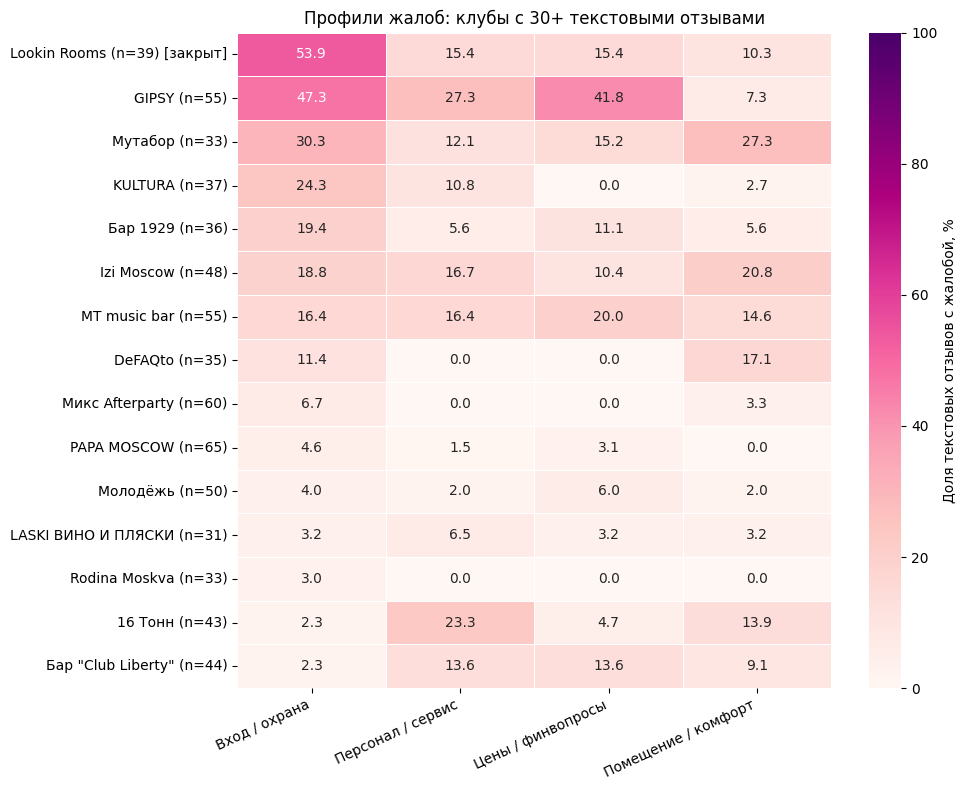

In [73]:
#heatmap
MIN_TEXT_REVIEWS = 30

plot_table = club_complaints.loc[
    club_complaints['reviews_count'] >= MIN_TEXT_REVIEWS
].copy()

data = plot_table[main_complaints]

labels = [
    'Вход / охрана',
    'Персонал / сервис',
    'Цены / финвопросы',
    'Помещение / комфорт',
]

ylabels = [
    f"{club} (n={int(plot_table.loc[club, 'reviews_count'])})"
    + (" [закрыт]" if club in closed_clubs else "")
    for club in data.index
]

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    data,
    annot=True,
    fmt='.1f',
    cmap='RdPu',
    vmin=0,
    vmax=100,
    linewidths=0.5,
    xticklabels=labels,
    yticklabels=ylabels,
    cbar_kws={'label': 'Доля текстовых отзывов с жалобой, %'},
    ax=ax,
)

ax.set_title('Профили жалоб: клубы с 30+ текстовыми отзывами')
ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

**Профиль жалоб заметно различается между заведениями.**

Среди клубов с 30+ текстовыми отзывами высокая доля жалоб на вход наблюдается у Lookin Rooms — 21 из 39, GIPSY — 26 из 55 и Мутабора — 10 из 33.  Эти наблюдения описывают собранные отзывы, а не долю недовольных среди всех посетителей.

Таким образом, проблемы на входе выглядят наиболее системным приоритетом, однако конкретный профиль проблем существенно различается между клубами. Это означает, что после определения общих рыночных приоритетов меры для отдельных заведений стоит выбирать с учетом их собственного профиля жалоб.

### 5.5 Итоговые выводы

Анализ 834 текстовых отзывов показал, что жалобы присутствуют примерно в 41% отзывов. Наиболее распространенная категория - проблемы на этапе входа, включая фейсконтроль и взаимодействие с охраной: они встречаются в 17,3% всех текстовых отзывов.

Приоритизация по частоте и индексу тяжести показывает, что проблемы на входе являются наиболее заметным направлением для улучшения клиентского опыта. Они одновременно встречаются чаще остальных категорий и сопровождаются наиболее низкими пользовательскими оценками (в среднем около 1,17 звезды). Вторым выраженным приоритетом выступают жалобы на персонал и сервис.

Некоторые проблемы, например безопасность и платный вход, также связаны с очень низкими оценками, однако встречаются значительно реже. Напротив, жалобы на помещение и комфорт относительно распространены, но сопровождаются менее негативными оценками.

Сравнение клубов показывает, что профиль проблем неоднороден. Высокая доля жалоб на вход наблюдается сразу у нескольких заведений, поэтому этот результат не определяется одним отдельным клубом. При этом для отдельных заведений более заметными становятся другие проблемы, такие как цены, сервис или комфорт помещения.

Таким образом, на уровне рынка основным направлением для улучшения клиентского опыта выглядит этап входа и взаимодействия с сотрудниками, контролирующими доступ. При этом для принятия решений на уровне конкретного клуба необходимо учитывать его индивидуальный профиль жалоб.